# Large-Scale Amazon Customer Review Analytics using PySpark
## Final Submission - Complete Pipeline, Objectives 1 to 9

**Ahsanullah University of Science and Technology**
Department of Computer Science and Engineering

**Course:** CSE 4262 - Data Analytics Lab  
**Lab Group:** Gr-03 | **Group:** Gr-06  
**Prepared for:** Mr. Md Hasan Al Kayem, Lecturer Grade-I and Dr. Afsana Ahmed Munia, Assistant Professor

| Student ID | Name |
|---|---|
| 20220104006 | A.S.M. Tahsin Tajware |
| 20220104014 | Abdullah Al Tamim |
| 20220104032 | Eusha Ahmed Mahi |


---

### Contents

| Section | Content |
|---|---|
| 1 | Spark session, dataset discovery, output folders |
| 2 | Schema-declared load and dataset profiling (Tables 1 to 6, Figure 1) |
| 3 | Preprocessing pipeline with a logged row-count audit trail |
| 4 | Feature engineering and the cached analytical DataFrame |
| 5 | **Objective 1** - customer satisfaction analysis |
| 6 | **Objective 2** - verified-purchase analysis |
| 7 | **Objective 3** - helpful-review analysis |
| 8 | **Objective 4** - temporal trend analysis |
| 9 | **Objective 5** - product-level analytics |
| 10 | **Objective 6** - customer-activity analysis |
| 11 | **Objective 7** - text analytics and lexicon sentiment |
| 12 | **Objective 8** - window-function based ranking |
| 13 | **Objective 9** - PySpark versus Pandas benchmark |
| 14 | Evaluation strategy: correctness audit and external consistency |
| 15 | Consolidated findings and deliverables |
| 16 | Conclusion |

Every table is written to `results/` as CSV and Parquet, and every figure to `figures/` as a
300 dpi PNG, so the report can be assembled directly from those folders.

**Requirement:** `Amazon_Reviews.csv` in the input folder. On Kaggle, attach the dataset and it
is found automatically. Expected runtime on the full extract is roughly 15 to 25 minutes,
dominated by Section 13.


## 1. Environment, Dataset and Output Folders

This section starts the Spark session, locates `Amazon_Reviews.csv`, and creates the folders
that every table and figure in this notebook is written to.


In [1]:
try:
    import pyspark
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pyspark"], check=True)
    import pyspark

import os, glob, time, gc, warnings
warnings.filterwarnings("ignore")

def find_dataset():
    hits = []
    for base in ["/kaggle/input", "/mnt/user-data/uploads", "./data", "."]:
        if os.path.isdir(base):
            hits += glob.glob(os.path.join(base, "**", "*.csv"), recursive=True)
    hits = [h for h in hits if "results" not in h and "figures" not in h]
    if not hits:
        raise FileNotFoundError("Amazon_Reviews.csv not found. Set DATA_PATH manually.")
    preferred = [h for h in hits if any(k in os.path.basename(h).lower()
                                        for k in ("amazon", "review"))]
    return sorted(preferred or hits, key=os.path.getsize, reverse=True)[0]

DATA_PATH = find_dataset()
OUT_DIR = "/kaggle/working" if os.path.isdir("/kaggle/working") else os.path.abspath("./output")
FIG_DIR = os.path.join(OUT_DIR, "figures")
TBL_DIR = os.path.join(OUT_DIR, "results")
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TBL_DIR, exist_ok=True)

print("PySpark version :", pyspark.__version__)
print("Dataset         :", DATA_PATH)
print("File size       : %.1f MB" % (os.path.getsize(DATA_PATH) / 1e6))
print("Figures folder  :", FIG_DIR)
print("Results folder  :", TBL_DIR)

PySpark version : 4.0.2
Dataset         : /kaggle/input/datasets/tahsintajware/dataaadvdv/Amazon_Reviews.csv
File size       : 174.5 MB
Figures folder  : /kaggle/working/figures
Results folder  : /kaggle/working/results


In [2]:
from pyspark.sql import SparkSession, Window
from pyspark.sql import functions as F
from pyspark.sql.types import (StructType, StructField, StringType, DoubleType,
                               LongType, IntegerType, BooleanType)

spark = (SparkSession.builder
         .appName("Large-Scale Amazon Customer Review Analytics - Gr-03")
         .master("local[*]")
         .config("spark.driver.memory", "8g")
         .config("spark.driver.maxResultSize", "2g")
         .config("spark.sql.shuffle.partitions", "16")
         .config("spark.sql.session.timeZone", "UTC")
         .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")

print("Spark version :", spark.version)
print("Master        :", spark.sparkContext.master)
print("Cores         :", spark.sparkContext.defaultParallelism)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/05 19:35:40 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version : 4.0.2
Master        : local[*]
Cores         : 4


In [3]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import numpy as np

plt.rcParams.update({
    "figure.figsize": (9, 5),
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
})

CATS = ["Cell Phones", "Video Games", "Beauty"]
CAT_COLORS = {"Cell Phones": "#2563eb", "Video Games": "#16a34a", "Beauty": "#db2777"}
STAR_COLORS = ["#ef4444", "#f97316", "#eab308", "#84cc16", "#16a34a"]
ACCENT = "#2563eb"
ccol = lambda c: CAT_COLORS.get(c, "#64748b")
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

RESULTS = {}
FIGURES = {}

def savefig(fig, name, caption=""):
    path = os.path.join(FIG_DIR, name + ".png")
    fig.savefig(path)
    FIGURES[name] = caption or name
    print("figure saved ->", path)

def save_table(obj, name, show=False, n=10):
    pdf = obj.toPandas() if hasattr(obj, "toPandas") else pd.DataFrame(obj).copy()
    pdf.to_csv(os.path.join(TBL_DIR, name + ".csv"), index=False)
    try:
        pdf.to_parquet(os.path.join(TBL_DIR, name + ".parquet"), index=False)
    except Exception as e:
        print("   parquet skipped:", type(e).__name__)
    RESULTS[name] = pdf
    print(f"table saved  -> {name}  ({len(pdf)} rows)")
    if show:
        print(pdf.head(n).to_string(index=False))
    return pdf

print("Plot style, figure saver and table saver ready.")

Plot style, figure saver and table saver ready.


## 2. Dataset Loading and Profiling

The schema is declared explicitly instead of relying on inference, so column types are fixed
and a malformed value cannot silently change a column's type. Profiling runs on the raw
DataFrame before any cleaning, because a null grouping key can quietly disappear from a
`groupBy` and go unnoticed otherwise.


In [4]:
schema = StructType([
    StructField("asin",              StringType(),  True),
    StructField("helpful_vote",      IntegerType(), True),
    StructField("images",            StringType(),  True),
    StructField("parent_asin",       StringType(),  True),
    StructField("rating",            DoubleType(),  True),
    StructField("text",              StringType(),  True),
    StructField("timestamp",         LongType(),    True),
    StructField("title",             StringType(),  True),
    StructField("user_id",           StringType(),  True),
    StructField("verified_purchase", BooleanType(), True),
    StructField("Category",          StringType(),  True),
])

CSV_OPTS = dict(header=True, quote='"', escape='"', multiLine=True, mode="PERMISSIVE")

def read_raw(tag=None):
    r = spark.read.options(**CSV_OPTS).schema(schema).csv(DATA_PATH)
    return r.withColumn("_src", F.lit(tag)) if tag else r

raw = read_raw().cache()
n_raw = raw.count()
print(f"Rows loaded: {n_raw:,}")
raw.printSchema()

Rows loaded: 521,607
root
 |-- asin: string (nullable = true)
 |-- helpful_vote: integer (nullable = true)
 |-- images: string (nullable = true)
 |-- parent_asin: string (nullable = true)
 |-- rating: double (nullable = true)
 |-- text: string (nullable = true)
 |-- timestamp: long (nullable = true)
 |-- title: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- verified_purchase: boolean (nullable = true)
 |-- Category: string (nullable = true)



In [5]:
raw.select("Category", "rating", "verified_purchase", "helpful_vote",
           F.substring("title", 1, 30).alias("title"),
           F.substring("text", 1, 55).alias("text_preview")).show(5, truncate=False)

+--------+------+-----------------+------------+------------------------------+-------------------------------------------------------+
|Category|rating|verified_purchase|helpful_vote|title                         |text_preview                                           |
+--------+------+-----------------+------------+------------------------------+-------------------------------------------------------+
|Beauty  |5.0   |false            |0           |Quality hair iron, works perfe|This is a great hair straightener. Heats up quickly and|
|Beauty  |5.0   |true             |0           |Doesn't Irritate My Skin      |A few months ago I got a vanity mirror that magnifies 5|
|Beauty  |4.0   |false            |0           |Slight Fading of Burns So Far |I burned my back of my hand in a couple of spots this p|
|Beauty  |2.0   |false            |0           |Lotion-zip, too heavily scente|I received this gift set for Christmas. My husband orde|
|Beauty  |5.0   |false            |2           |

### 2.1 Table 1 - Dataset summary

`None`, `NaN`, `NULL` and empty strings are all treated as missing, matching how pandas reads
the same file, so the missing-value counts here are comparable to the proposal.


In [6]:
NA_TOKENS = ['', '#N/A', '#N/A N/A', '#NA', '-1.#IND', '-1.#QNAN', '-NaN', '-nan',
             '1.#IND', '1.#QNAN', '<NA>', 'N/A', 'NA', 'NULL', 'NaN', 'None', 'n/a', 'nan', 'null']

def missing(colname):
    c = F.col(colname)
    return c.isNull() | c.isin(NA_TOKENS)

summary = raw.select(
    F.count("*").alias("total_records"),
    F.countDistinct("user_id").alias("unique_reviewers"),
    F.countDistinct("asin").alias("unique_products"),
    F.countDistinct("parent_asin").alias("unique_parent_products"),
    F.sum(F.col("verified_purchase").cast("int")).alias("verified"),
    F.sum((~F.col("verified_purchase")).cast("int")).alias("non_verified"),
    F.sum(missing("text").cast("int")).alias("missing_text"),
    F.sum(missing("title").cast("int")).alias("missing_title"),
    F.min((F.col("timestamp") / 1000).cast("timestamp")).alias("earliest"),
    F.max((F.col("timestamp") / 1000).cast("timestamp")).alias("latest"),
).first()

tot = summary["total_records"]
tbl1 = pd.DataFrame([
    ("Total records",           f"{tot:,} customer reviews"),
    ("Date range",              f"{summary['earliest'].date()} to {summary['latest'].date()}"),
    ("Categories",              ", ".join(CATS)),
    ("Verified / non-verified", f"{summary['verified']:,} ({summary['verified']/tot:.1%}) / "
                                f"{summary['non_verified']:,} ({summary['non_verified']/tot:.1%})"),
    ("Unique reviewers",        f"{summary['unique_reviewers']:,}"),
    ("Unique products (asin)",  f"{summary['unique_products']:,}"),
    ("Unique parent products",  f"{summary['unique_parent_products']:,}"),
    ("Missing review text",     f"{summary['missing_text']} ({summary['missing_text']/tot:.3%})"),
    ("Missing review title",    f"{summary['missing_title']} ({summary['missing_title']/tot:.3%})"),
], columns=["Attribute", "Value"])

print("Table 1 - Dataset summary")
save_table(tbl1, "tbl01_dataset_summary")
tbl1

Table 1 - Dataset summary
table saved  -> tbl01_dataset_summary  (9 rows)


,Attribute,Value
0,Total records,"521,607 customer reviews"
1,Date range,1999-09-17 to 2023-09-11
2,Categories,"Cell Phones, Video Games, Beauty"
3,Verified / non-verified,"485,784 (93.1%) / 35,823 (6.9%)"
4,Unique reviewers,"504,856"
5,Unique products (asin),"227,791"
6,Unique parent products,"193,816"
7,Missing review text,186 (0.036%)
8,Missing review title,156 (0.030%)


### 2.2 Tables 2 and 3 - Category and rating distribution

In [7]:
cat_dist = (raw.groupBy("Category").count()
            .withColumn("share_pct", F.round(100 * F.col("count") / tot, 1))
            .orderBy(F.desc("count")))
rating_dist = (raw.groupBy("rating").count()
               .withColumn("share_pct", F.round(100 * F.col("count") / tot, 1))
               .orderBy("rating"))

print("Table 2 - Category distribution")
cat_dist.show(truncate=False)
print("Table 3 - Rating distribution (marketplace-wide)")
rating_dist.show(truncate=False)

save_table(cat_dist, "tbl02_category_distribution")
save_table(rating_dist, "tbl03_rating_distribution");

Table 2 - Category distribution
+-----------+------+---------+
|Category   |count |share_pct|
+-----------+------+---------+
|Cell Phones|415467|79.7     |
|Video Games|91966 |17.6     |
|Beauty     |14174 |2.7      |
+-----------+------+---------+

Table 3 - Rating distribution (marketplace-wide)
+------+------+---------+
|rating|count |share_pct|
+------+------+---------+
|1.0   |69518 |13.3     |
|2.0   |30771 |5.9      |
|3.0   |38826 |7.4      |
|4.0   |62515 |12.0     |
|5.0   |319977|61.3     |
+------+------+---------+

table saved  -> tbl02_category_distribution  (3 rows)
table saved  -> tbl03_rating_distribution  (5 rows)


### 2.3 Tables 4 and 5 - Rating by category, and review length by rating

In [8]:
cat_stats = (raw.groupBy("Category")
             .agg(F.round(F.avg("rating"), 2).alias("avg_rating"),
                  F.round(100 * F.avg(F.col("verified_purchase").cast("int")), 1).alias("verified_share_pct"),
                  F.count("*").alias("reviews"))
             .orderBy(F.desc("avg_rating")))

len_by_rating = (raw.withColumn("len", F.length(F.coalesce(F.col("text"), F.lit(""))))
                 .groupBy("rating")
                 .agg(F.round(F.avg("len")).cast("int").alias("avg_len_chars"))
                 .orderBy("rating"))

print("Table 4 - Average rating and verified share by category")
cat_stats.show(truncate=False)
print("Table 5 - Average review-text length by star rating")
len_by_rating.show(truncate=False)

save_table(cat_stats, "tbl04_category_stats")
save_table(len_by_rating, "tbl05_length_by_rating");

Table 4 - Average rating and verified share by category
+-----------+----------+------------------+-------+
|Category   |avg_rating|verified_share_pct|reviews|
+-----------+----------+------------------+-------+
|Video Games|4.05      |86.0              |91966  |
|Cell Phones|4.02      |94.8              |415467 |
|Beauty     |3.96      |90.5              |14174  |
+-----------+----------+------------------+-------+

Table 5 - Average review-text length by star rating


+------+-------------+
|rating|avg_len_chars|
+------+-------------+
|1.0   |202          |
|2.0   |275          |
|3.0   |280          |
|4.0   |283          |
|5.0   |164          |
+------+-------------+

table saved  -> tbl04_category_stats  (3 rows)
table saved  -> tbl05_length_by_rating  (5 rows)


### 2.4 Engagement profile of helpful votes

Helpful votes are the most skewed field in the dataset. The median and 75th percentile both sit
at zero while a handful of reviews collect thousands of votes, so the mean on its own is
misleading and any helpfulness feature has to be built with that skew in mind.


In [9]:
q = raw.approxQuantile("helpful_vote", [0.5, 0.75, 0.9, 0.99], 0.001)
hv_stats = raw.select(
    F.round(F.avg("helpful_vote"), 3).alias("mean"),
    F.max("helpful_vote").alias("max"),
    F.round(100 * F.avg((F.col("helpful_vote") >= 1).cast("int")), 1).alias("pct_with_any_vote"),
).first()

tbl_hv = pd.DataFrame([
    ("Mean helpful votes",       hv_stats["mean"]),
    ("Median (p50)",             q[0]),
    ("75th percentile",          q[1]),
    ("90th percentile",          q[2]),
    ("99th percentile",          q[3]),
    ("Maximum",                  hv_stats["max"]),
    ("Reviews with >=1 vote (%)", hv_stats["pct_with_any_vote"]),
], columns=["Statistic", "Value"])

print("Helpful-vote engagement profile")
save_table(tbl_hv, "tbl06_helpful_vote_profile")
tbl_hv

Helpful-vote engagement profile
table saved  -> tbl06_helpful_vote_profile  (7 rows)


,Statistic,Value
0,Mean helpful votes,0.704
1,Median (p50),0.000
2,75th percentile,0.000
3,90th percentile,1.000
4,99th percentile,11.000
5,Maximum,"7,663.000"
6,Reviews with >=1 vote (%),17.100


### 2.5 Figure 1 - Profiling overview

figure saved -> /kaggle/working/figures/fig01_dataset_profile.png


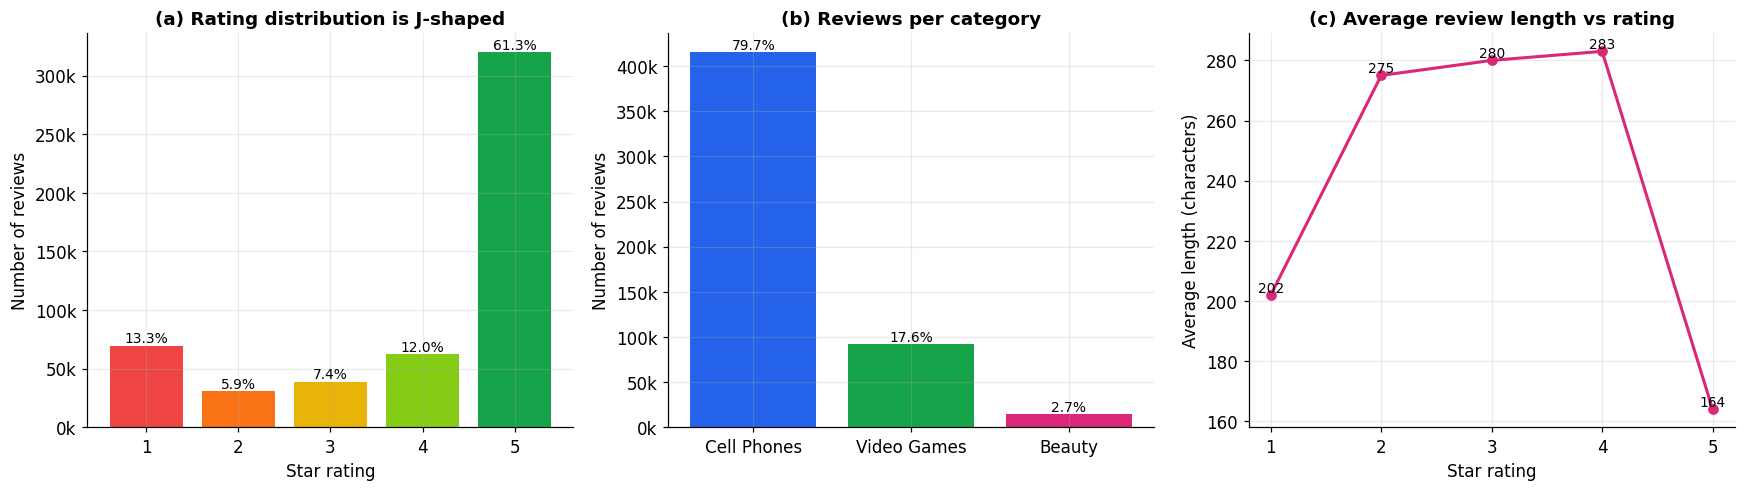

In [10]:
rd, cd, lbr = rating_dist.toPandas(), cat_dist.toPandas(), len_by_rating.toPandas()

fig, ax = plt.subplots(1, 3, figsize=(16, 4.6))

bars = ax[0].bar(rd["rating"].astype(int).astype(str), rd["count"], color=STAR_COLORS)
ax[0].set_title("(a) Rating distribution is J-shaped")
ax[0].set_xlabel("Star rating"); ax[0].set_ylabel("Number of reviews")
ax[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
for b, s in zip(bars, rd["share_pct"]):
    ax[0].text(b.get_x() + b.get_width()/2, b.get_height(), f"{s}%", ha="center", va="bottom", fontsize=9)

ax[1].bar(cd["Category"], cd["count"], color=[ccol(c) for c in cd["Category"]])
ax[1].set_title("(b) Reviews per category"); ax[1].set_ylabel("Number of reviews")
ax[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
for i, (c, s) in enumerate(zip(cd["count"], cd["share_pct"])):
    ax[1].text(i, c, f"{s}%", ha="center", va="bottom", fontsize=9)

ax[2].plot(lbr["rating"].astype(int), lbr["avg_len_chars"], marker="o", color="#db2777", lw=2)
ax[2].set_title("(c) Average review length vs rating")
ax[2].set_xlabel("Star rating"); ax[2].set_ylabel("Average length (characters)")
ax[2].set_xticks([1, 2, 3, 4, 5])
for x, y in zip(lbr["rating"].astype(int), lbr["avg_len_chars"]):
    ax[2].text(x, y, f"{y}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
savefig(fig, "fig01_dataset_profile", "Rating skew, category mix and length-by-rating")
plt.show()

## 3. Data Preprocessing

Four steps run in order, and the row count is logged after each one so any unexpected data loss
is visible instead of silent.

1. Missing-value sentinels are converted to real nulls.
2. The Unix-millisecond timestamp is parsed and calendar features are derived.
3. Ratings are range-checked to the valid 1 to 5 band.
4. Duplicate reviews (same user, product and timestamp) are dropped, empty review bodies are
   removed, and a missing title is filled with an empty string rather than dropping the row.


In [11]:
preprocess_log = []

def log_step(step, frame):
    n = frame.count()
    preprocess_log.append((step, n))
    print(f"{step:<38} rows = {n:,}")
    return frame

def norm(colname):
    c = F.col(colname)
    return F.when(c.isin(NA_TOKENS), None).otherwise(c)

df = raw
log_step("0. raw as loaded", df)

df = df.withColumn("text", norm("text")).withColumn("title", norm("title"))
log_step("1. sentinels converted to null", df)

df = (df.withColumn("event_time", (F.col("timestamp") / 1000).cast("timestamp"))
        .withColumn("review_year", F.year("event_time"))
        .withColumn("review_month", F.month("event_time")))
log_step("2. timestamp parsed", df)

df = df.filter((F.col("rating") >= 1) & (F.col("rating") <= 5))
log_step("3. rating range-checked", df)

df = df.dropDuplicates(["user_id", "asin", "timestamp"])
log_step("4a. duplicates removed", df)

df = (df.filter(F.col("text").isNotNull())
        .withColumn("title", F.coalesce(F.col("title"), F.lit(""))))
log_step("4b. empty review bodies dropped", df);

0. raw as loaded                       rows = 521,607
1. sentinels converted to null         rows = 521,607
2. timestamp parsed                    rows = 521,607
3. rating range-checked                rows = 521,607


4a. duplicates removed                 rows = 521,459


4b. empty review bodies dropped        rows = 521,273


In [12]:
log_pdf = pd.DataFrame(preprocess_log, columns=["step", "rows"])
log_pdf["removed"] = (log_pdf["rows"].shift(1) - log_pdf["rows"]).fillna(0).astype(int)
log_pdf["retained_pct"] = (100 * log_pdf["rows"] / log_pdf["rows"].iloc[0]).round(3)

print(f"Rows retained after cleaning: {log_pdf['rows'].iloc[-1]:,} "
      f"({log_pdf['retained_pct'].iloc[-1]:.2f}% of {log_pdf['rows'].iloc[0]:,})")
save_table(log_pdf, "tbl07_preprocessing_audit")
log_pdf

Rows retained after cleaning: 521,273 (99.94% of 521,607)
table saved  -> tbl07_preprocessing_audit  (6 rows)


,step,rows,removed,retained_pct
0,0. raw as loaded,521607,0,100.000
1,1. sentinels converted to null,521607,0,100.000
2,2. timestamp parsed,521607,0,100.000
3,3. rating range-checked,521607,0,100.000
4,4a. duplicates removed,521459,148,99.972
5,4b. empty review bodies dropped,521273,186,99.936


## 4. Feature Engineering

The derived columns are computed once and the resulting DataFrame is cached, so every objective
below reads the same in-memory working set instead of recomputing the pipeline. This is the
in-memory reuse that Spark is built around, and it is what makes a nine-module pipeline
practical on one machine.


In [13]:
HIGHLY_HELPFUL_THRESHOLD = 10

df = (df
      .withColumn("review_length", F.length("text"))
      .withColumn("review_word_count",
                  F.when(F.trim("text") == "", 0)
                   .otherwise(F.size(F.split(F.trim("text"), r"\s+"))))
      .withColumn("log_helpful_vote", F.round(F.log1p(F.col("helpful_vote")), 4))
      .withColumn("is_highly_helpful",
                  (F.col("helpful_vote") >= HIGHLY_HELPFUL_THRESHOLD).cast("int")))

prod_agg = (df.groupBy("parent_asin")
              .agg(F.round(F.avg("rating"), 3).alias("product_avg_rating"),
                   F.count("*").alias("product_review_count")))
df = df.join(prod_agg, on="parent_asin", how="left").cache()

n_clean = df.count()
print(f"Analytical dataset cached: {n_clean:,} rows x {len(df.columns)} columns")
df.select("Category", "rating", "verified_purchase", "helpful_vote", "review_length",
          "review_word_count", "log_helpful_vote", "is_highly_helpful", "review_year",
          "product_avg_rating", "product_review_count").show(5)

Analytical dataset cached: 521,273 rows x 20 columns
+-----------+------+-----------------+------------+-------------+-----------------+----------------+-----------------+-----------+------------------+--------------------+
|   Category|rating|verified_purchase|helpful_vote|review_length|review_word_count|log_helpful_vote|is_highly_helpful|review_year|product_avg_rating|product_review_count|
+-----------+------+-----------------+------------+-------------+-----------------+----------------+-----------------+-----------+------------------+--------------------+
|Video Games|   5.0|             true|           0|          108|               18|             0.0|                0|       2016|               5.0|                   1|
|Cell Phones|   5.0|            false|           0|          172|               30|             0.0|                0|       2017|               5.0|                   2|
|Cell Phones|   5.0|            false|           2|          107|               20|         

## 5. Objective 1 - Customer Satisfaction Analysis

The marketplace-wide average and the full 1 to 5 distribution, then the same measures split by
category to see whether satisfaction holds steady across product types that are as different as
phones, games and beauty products.


In [14]:
overall = df.agg(F.round(F.avg("rating"), 3).alias("avg"), F.count("*").alias("n")).first()
print(f"Marketplace-wide average rating: {overall['avg']}  (n = {overall['n']:,})")

sat_overall = (df.groupBy("rating").count()
               .withColumn("pct", F.round(100 * F.col("count") / overall["n"], 1))
               .orderBy("rating"))
sat_overall.show()

sat_by_cat = (df.groupBy("Category")
              .agg(F.round(F.avg("rating"), 3).alias("avg_rating"),
                   F.round(100 * F.avg((F.col("rating") >= 4).cast("int")), 1).alias("pct_4_or_5"),
                   F.round(100 * F.avg((F.col("rating") <= 2).cast("int")), 1).alias("pct_1_or_2"),
                   F.count("*").alias("reviews"))
              .orderBy(F.desc("avg_rating")))
print("Average rating and positive share by category")
sat_by_cat.show(truncate=False)

save_table(sat_overall, "obj1_rating_distribution")
save_table(sat_by_cat, "obj1_satisfaction_by_category");

Marketplace-wide average rating: 4.021  (n = 521,273)
+------+------+----+
|rating| count| pct|
+------+------+----+
|   1.0| 69480|13.3|
|   2.0| 30760| 5.9|
|   3.0| 38799| 7.4|
|   4.0| 62481|12.0|
|   5.0|319753|61.3|
+------+------+----+

Average rating and positive share by category
+-----------+----------+----------+----------+-------+
|Category   |avg_rating|pct_4_or_5|pct_1_or_2|reviews|
+-----------+----------+----------+----------+-------+
|Video Games|4.049     |74.5      |18.2      |91920  |
|Cell Phones|4.017     |73.1      |19.4      |415185 |
|Beauty     |3.959     |71.1      |20.7      |14168  |
+-----------+----------+----------+----------+-------+

table saved  -> obj1_rating_distribution  (5 rows)
table saved  -> obj1_satisfaction_by_category  (3 rows)


In [15]:
cat_tot = df.groupBy("Category").count().withColumnRenamed("count", "cat_total")
cat_mix = (df.groupBy("Category", "rating").count()
           .join(cat_tot, "Category")
           .withColumn("share", 100 * F.col("count") / F.col("cat_total"))
           .groupBy("Category").pivot("rating", [1.0, 2.0, 3.0, 4.0, 5.0])
           .agg(F.round(F.first("share"), 1)))
print("Rating mix within each category (percent of that category's reviews)")
cat_mix.show()
save_table(cat_mix, "obj1_rating_mix_by_category");

Rating mix within each category (percent of that category's reviews)


+-----------+----+---+---+----+----+
|   Category| 1.0|2.0|3.0| 4.0| 5.0|
+-----------+----+---+---+----+----+
|     Beauty|14.3|6.4|8.3|11.4|59.7|
|Video Games|12.7|5.5|7.3|13.2|61.3|
|Cell Phones|13.4|6.0|7.4|11.7|61.4|
+-----------+----+---+---+----+----+



table saved  -> obj1_rating_mix_by_category  (3 rows)


figure saved -> /kaggle/working/figures/fig02_customer_satisfaction.png


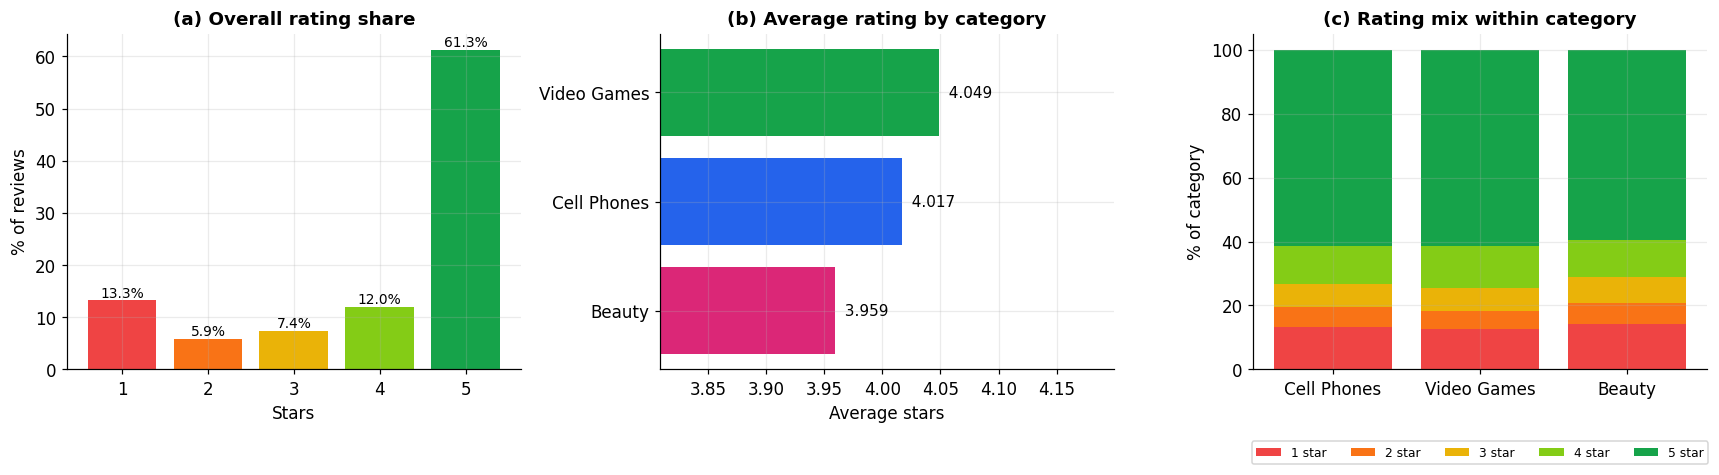

In [16]:
so = sat_overall.toPandas()
sbc = sat_by_cat.toPandas().sort_values("avg_rating")
pv = cat_mix.toPandas().set_index("Category")
pv.columns = [str(c) for c in pv.columns]
pv = pv.reindex([c for c in CATS if c in pv.index])

fig, ax = plt.subplots(1, 3, figsize=(16, 4.6))

ax[0].bar(so["rating"].astype(int).astype(str), so["pct"], color=STAR_COLORS)
ax[0].set_title("(a) Overall rating share"); ax[0].set_xlabel("Stars"); ax[0].set_ylabel("% of reviews")
for i, p in enumerate(so["pct"]):
    ax[0].text(i, p, f"{p}%", ha="center", va="bottom", fontsize=9)

ax[1].barh(sbc["Category"], sbc["avg_rating"], color=[ccol(c) for c in sbc["Category"]])
lo, hi = sbc["avg_rating"].min(), sbc["avg_rating"].max()
ax[1].set_xlim(max(0, lo - 0.15), hi + 0.15)
ax[1].set_title("(b) Average rating by category"); ax[1].set_xlabel("Average stars")
for i, v in enumerate(sbc["avg_rating"]):
    ax[1].text(v, i, f"  {v}", va="center", fontsize=10)

bottom = np.zeros(len(pv))
for star, col in zip(["1.0", "2.0", "3.0", "4.0", "5.0"], STAR_COLORS):
    if star not in pv.columns:
        continue
    vals = pv[star].astype(float).values
    ax[2].bar(pv.index, vals, bottom=bottom, label=f"{star[0]} star", color=col)
    bottom = bottom + vals
ax[2].set_title("(c) Rating mix within category"); ax[2].set_ylabel("% of category")
ax[2].legend(ncol=5, fontsize=8, loc="lower center", bbox_to_anchor=(0.5, -0.30))

plt.tight_layout()
savefig(fig, "fig02_customer_satisfaction", "Objective 1 - satisfaction overall and by category")
plt.show()

## 6. Objective 2 - Verified-Purchase Analysis

Verified and non-verified reviews are compared on rating, helpful votes and length. The
differences are reported descriptively. A gap here is not evidence of fraud, because a verified
badge can still sit on a manipulated review when a seller supplies a free unit, so the badge is
treated as something to measure rather than a settled trust signal.


In [17]:
verified_cmp = (df.groupBy("verified_purchase")
                .agg(F.count("*").alias("reviews"),
                     F.round(100 * F.count("*") / n_clean, 1).alias("share_pct"),
                     F.round(F.avg("rating"), 3).alias("avg_rating"),
                     F.round(F.avg("helpful_vote"), 3).alias("avg_helpful_vote"),
                     F.round(F.avg("review_length"), 1).alias("avg_review_length"),
                     F.round(100 * F.avg((F.col("rating") >= 4).cast("int")), 1).alias("pct_positive"))
                .orderBy(F.desc("verified_purchase")))
verified_cmp.show(truncate=False)

verified_by_cat = (df.groupBy("Category", "verified_purchase")
                   .agg(F.round(F.avg("rating"), 3).alias("avg_rating"),
                        F.count("*").alias("reviews"))
                   .orderBy("Category", F.desc("verified_purchase")))
print("Verified vs non-verified within each category")
verified_by_cat.show(truncate=False)

save_table(verified_cmp, "obj2_verified_comparison")
save_table(verified_by_cat, "obj2_verified_by_category");

+-----------------+-------+---------+----------+----------------+-----------------+------------+
|verified_purchase|reviews|share_pct|avg_rating|avg_helpful_vote|avg_review_length|pct_positive|
+-----------------+-------+---------+----------+----------------+-----------------+------------+
|true             |485468 |93.1     |4.031     |0.614           |174.6            |73.6        |
|false            |35805  |6.9      |3.886     |1.928           |524.9            |70.0        |
+-----------------+-------+---------+----------+----------------+-----------------+------------+

Verified vs non-verified within each category
+-----------+-----------------+----------+-------+
|Category   |verified_purchase|avg_rating|reviews|
+-----------+-----------------+----------+-------+
|Beauty     |true             |3.943     |12823  |
|Beauty     |false            |4.104     |1345   |
|Cell Phones|true             |4.02      |393593 |
|Cell Phones|false            |3.967     |21592  |
|Video Games|t

figure saved -> /kaggle/working/figures/fig03_verified_purchase.png


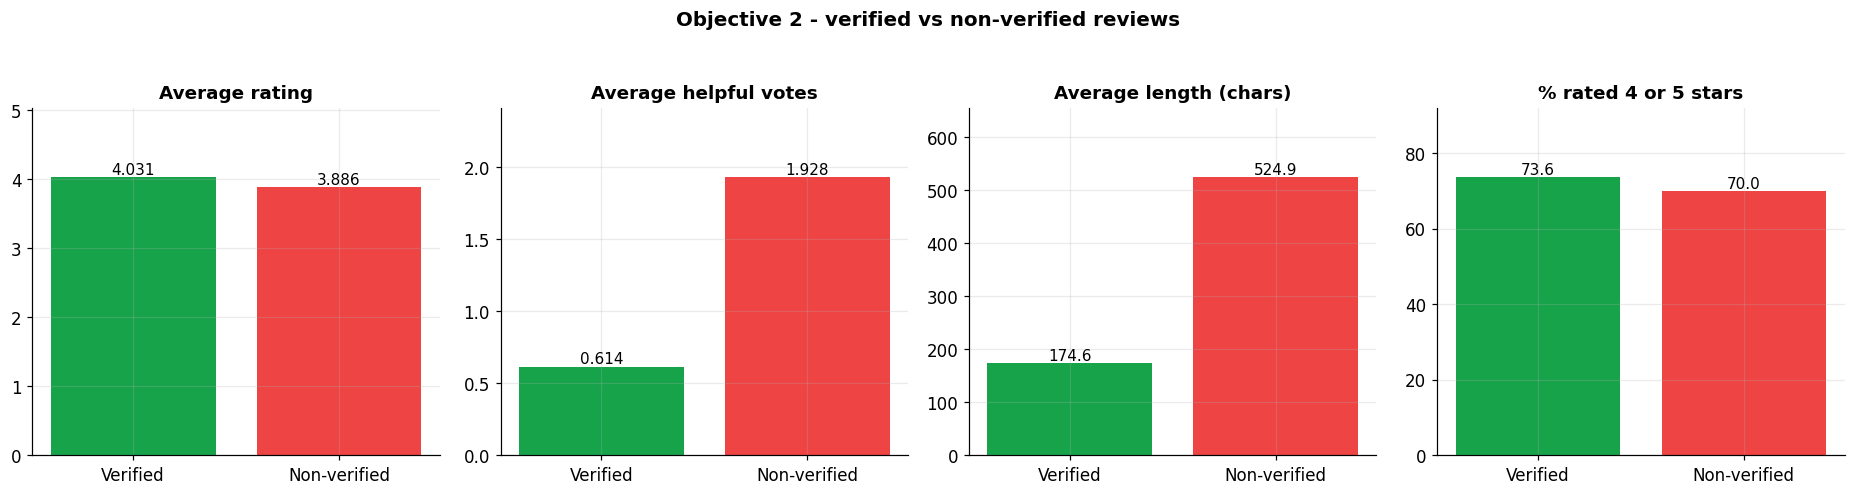

In [18]:
vc = verified_cmp.toPandas()
vc["group"] = vc["verified_purchase"].map({True: "Verified", False: "Non-verified"})
palette = {"Verified": "#16a34a", "Non-verified": "#ef4444"}

fig, ax = plt.subplots(1, 4, figsize=(17, 4.3))
panels = [("avg_rating", "Average rating"), ("avg_helpful_vote", "Average helpful votes"),
          ("avg_review_length", "Average length (chars)"), ("pct_positive", "% rated 4 or 5 stars")]
for a, (col, title) in zip(ax, panels):
    a.bar(vc["group"], vc[col], color=[palette[g] for g in vc["group"]])
    a.set_title(title)
    a.set_ylim(0, vc[col].max() * 1.25)
    for i, v in enumerate(vc[col]):
        a.text(i, v, f"{v}", ha="center", va="bottom", fontsize=10)

plt.suptitle("Objective 2 - verified vs non-verified reviews", y=1.04, fontsize=13, fontweight="bold")
plt.tight_layout()
savefig(fig, "fig03_verified_purchase", "Objective 2 - verified vs non-verified behaviour")
plt.show()

## 7. Objective 3 - Helpful-Review Analysis

In [19]:
top_helpful = (df.select("helpful_vote", "rating", "Category", "review_length",
                         F.substring("title", 1, 45).alias("title"),
                         F.substring("text", 1, 60).alias("text_preview"))
               .orderBy(F.desc("helpful_vote")).limit(10))
print("Top 10 most-helpful reviews")
top_helpful.show(truncate=False)

help_by_rating = (df.groupBy("rating")
                  .agg(F.round(F.avg("helpful_vote"), 3).alias("avg_helpful"),
                       F.max("helpful_vote").alias("max_helpful"),
                       F.round(100 * F.avg((F.col("helpful_vote") >= 1).cast("int")), 1).alias("pct_with_vote"),
                       F.round(100 * F.avg("is_highly_helpful"), 2).alias("pct_highly_helpful"))
                  .orderBy("rating"))
overall_help = df.agg(F.round(F.avg("helpful_vote"), 3).alias("avg"),
                      F.round(100 * F.avg((F.col("helpful_vote") >= 1).cast("int")), 1).alias("pct_any")).first()
print(f"Overall: average helpful votes = {overall_help['avg']}, "
      f"reviews with at least one vote = {overall_help['pct_any']}%")
help_by_rating.show()

save_table(top_helpful, "obj3_top_helpful_reviews")
save_table(help_by_rating, "obj3_helpful_by_rating");

Top 10 most-helpful reviews


+------------+------+-----------+-------------+---------------------------------------------+------------------------------------------------------------+
|helpful_vote|rating|Category   |review_length|title                                        |text_preview                                                |
+------------+------+-----------+-------------+---------------------------------------------+------------------------------------------------------------+
|7663        |1.0   |Video Games|119          |Worse Launch In Game History                 |Between Nvidia, Sony and Microsoft,  They all suck at launch|
|2841        |1.0   |Video Games|72           |Not wireless                                 |When I cut off the cord to make it wireless, didn't work, do|
|1821        |5.0   |Video Games|3037         |Great value for the 50 dollar range headsets |FIrst off, this is a great value for the money, its hands-do|
|1481        |5.0   |Cell Phones|87           |The camera part is hard

figure saved -> /kaggle/working/figures/fig04_helpful_reviews.png


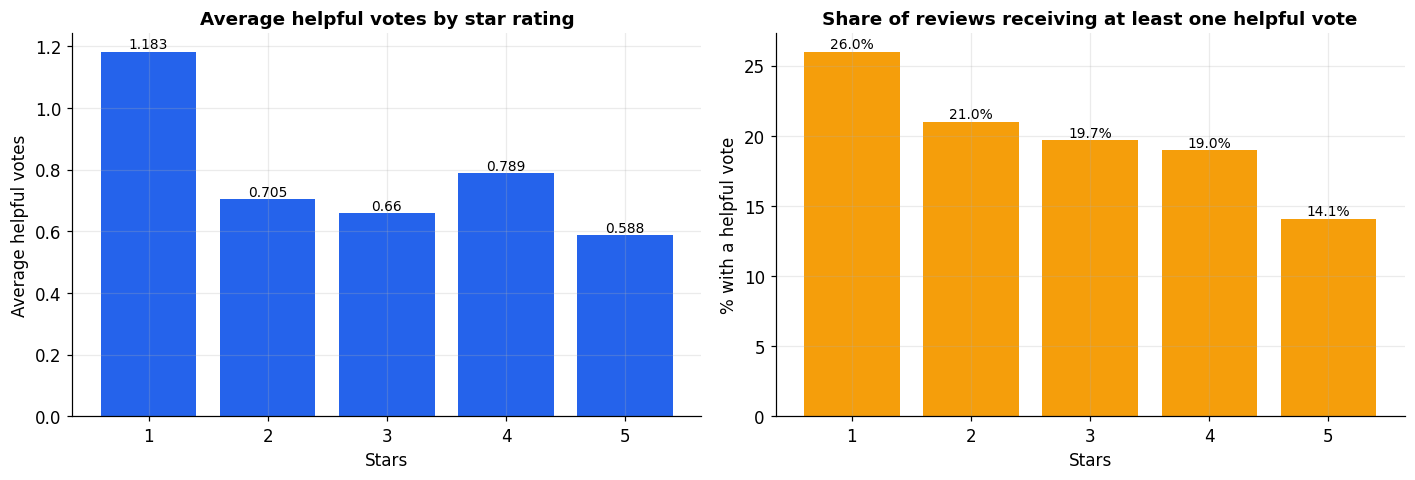

In [20]:
hbr = help_by_rating.toPandas()
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

ax[0].bar(hbr["rating"].astype(int).astype(str), hbr["avg_helpful"], color=ACCENT)
ax[0].set_title("Average helpful votes by star rating")
ax[0].set_xlabel("Stars"); ax[0].set_ylabel("Average helpful votes")
for i, v in enumerate(hbr["avg_helpful"]):
    ax[0].text(i, v, f"{v}", ha="center", va="bottom", fontsize=9)

ax[1].bar(hbr["rating"].astype(int).astype(str), hbr["pct_with_vote"], color="#f59e0b")
ax[1].set_title("Share of reviews receiving at least one helpful vote")
ax[1].set_xlabel("Stars"); ax[1].set_ylabel("% with a helpful vote")
for i, v in enumerate(hbr["pct_with_vote"]):
    ax[1].text(i, v, f"{v}%", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
savefig(fig, "fig04_helpful_reviews", "Objective 3 - helpfulness by star rating")
plt.show()

## 8. Objective 4 - Temporal Trend Analysis

In [21]:
yearly = (df.groupBy("review_year")
          .agg(F.count("*").alias("reviews"),
               F.round(F.avg("rating"), 3).alias("avg_rating"),
               F.round(F.avg("helpful_vote"), 3).alias("avg_helpful"),
               F.round(F.avg("review_length"), 1).alias("avg_length"))
          .orderBy("review_year"))
print("Yearly review volume, rating and engagement")
yearly.show(40, truncate=False)

n_surge = df.filter(F.col("review_year").between(2019, 2021)).count()
n_before = df.filter(F.col("review_year").between(2016, 2018)).count()
peak = yearly.orderBy(F.desc("reviews")).first()
print(f"Reviews 2019-2021: {n_surge:,} vs 2016-2018: {n_before:,} "
      f"(x{n_surge/max(n_before,1):.1f})")
print(f"Busiest year: {peak['review_year']} with {peak['reviews']:,} reviews")

save_table(yearly, "obj4_yearly_trend");

Yearly review volume, rating and engagement
+-----------+-------+----------+-----------+----------+
|review_year|reviews|avg_rating|avg_helpful|avg_length|
+-----------+-------+----------+-----------+----------+
|1999       |15     |4.467     |10.067     |568.5     |
|2000       |87     |4.31      |6.207      |884.3     |
|2001       |219    |4.091     |5.251      |985.4     |
|2002       |287    |4.056     |4.373      |900.3     |
|2003       |278    |4.126     |3.522      |1058.1    |
|2004       |319    |3.984     |5.038      |1194.1    |
|2005       |394    |3.832     |6.657      |1268.8    |
|2006       |382    |3.809     |9.534      |1237.7    |
|2007       |747    |3.921     |5.469      |830.3     |
|2008       |985    |3.789     |4.077      |788.7     |
|2009       |1350   |3.897     |3.05       |748.7     |
|2010       |2041   |3.85      |3.007      |745.1     |
|2011       |3571   |3.861     |2.513      |646.2     |
|2012       |6468   |3.912     |1.764      |487.9     |
|201

figure saved -> /kaggle/working/figures/fig05_temporal_trend.png


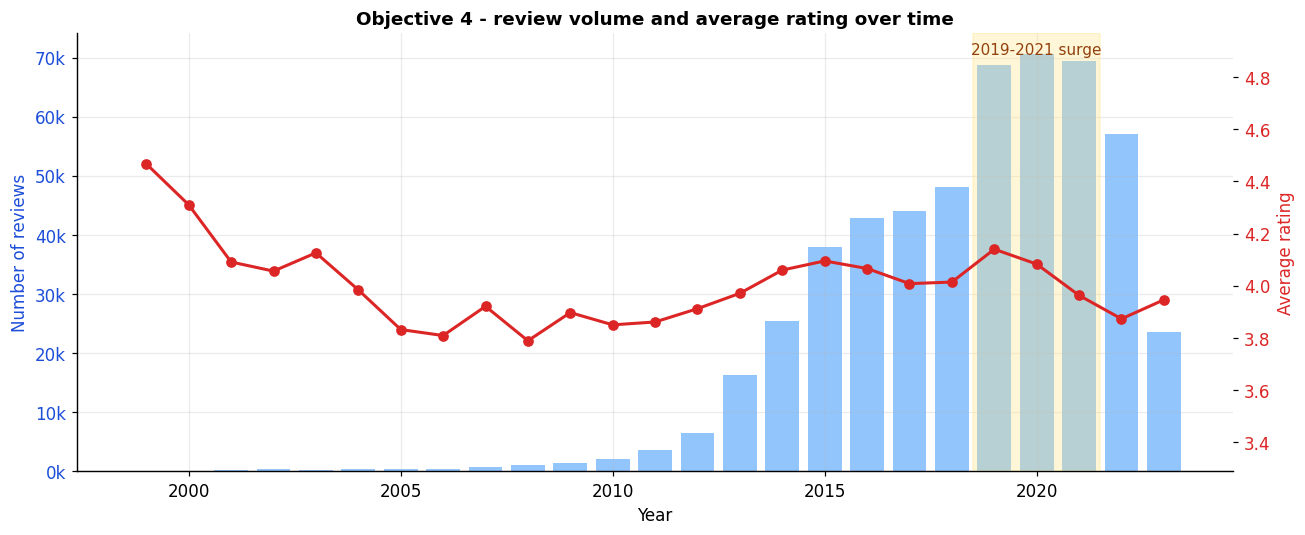

In [22]:
yr = yearly.toPandas()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.bar(yr["review_year"], yr["reviews"], color="#93c5fd", label="Review volume")
ax1.set_xlabel("Year"); ax1.set_ylabel("Number of reviews", color="#1d4ed8")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
ax1.tick_params(axis="y", labelcolor="#1d4ed8")

ax2 = ax1.twinx()
ax2.plot(yr["review_year"], yr["avg_rating"], color="#dc2626", marker="o", lw=2, label="Average rating")
ax2.set_ylabel("Average rating", color="#dc2626")
ax2.set_ylim(max(1, yr["avg_rating"].min() - 0.5), min(5.05, yr["avg_rating"].max() + 0.5))
ax2.tick_params(axis="y", labelcolor="#dc2626"); ax2.grid(False)
ax2.axvspan(2018.5, 2021.5, color="#fde68a", alpha=0.35)
ax2.annotate("2019-2021 surge", xy=(2020, ax2.get_ylim()[1] - 0.08),
             ha="center", fontsize=10, color="#92400e")

plt.title("Objective 4 - review volume and average rating over time")
fig.tight_layout()
savefig(fig, "fig05_temporal_trend", "Objective 4 - volume and rating, 1999 to 2023")
plt.show()

figure saved -> /kaggle/working/figures/fig06_category_trend.png


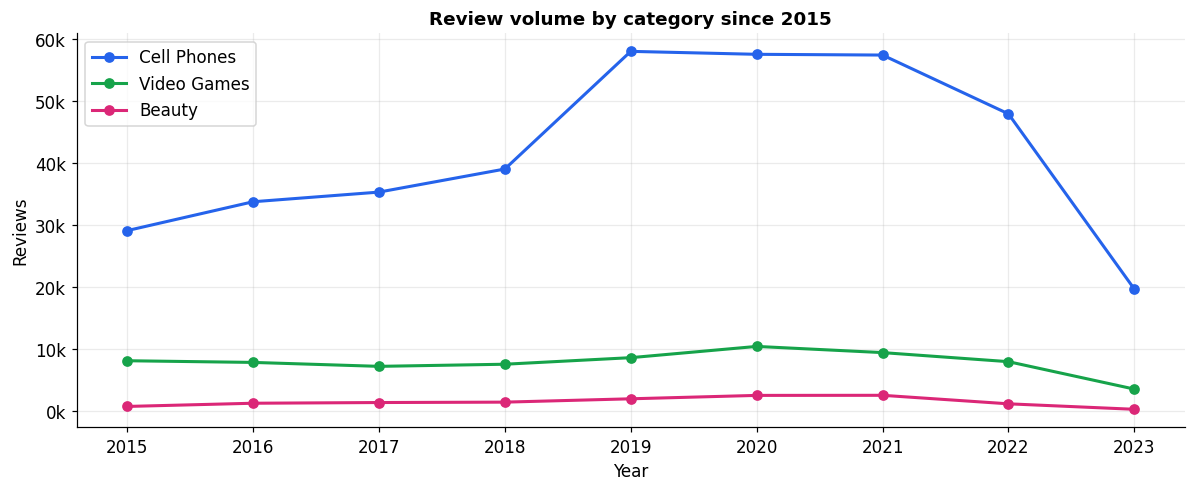

table saved  -> obj4_category_yearly  (27 rows)


In [23]:
cat_year = (df.filter(F.col("review_year") >= 2015)
            .groupBy("review_year", "Category").count().orderBy("review_year"))
cy = cat_year.toPandas()

fig, ax = plt.subplots(figsize=(11, 4.6))
for cat in CATS:
    sub = cy[cy["Category"] == cat]
    if len(sub):
        ax.plot(sub["review_year"], sub["count"], marker="o", label=cat, color=ccol(cat), lw=2)
ax.set_title("Review volume by category since 2015")
ax.set_xlabel("Year"); ax.set_ylabel("Reviews")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
ax.legend()
plt.tight_layout()
savefig(fig, "fig06_category_trend", "Objective 4 - per-category volume since 2015")
plt.show()

save_table(cat_year, "obj4_category_yearly");

## 9. Objective 5 - Product-Level Analytics

Average rating alone compresses most products into a narrow, high band, and a product with three
five-star reviews would otherwise top the table. A minimum-review threshold is applied before
ranking, and the review count is reported next to every rank so the reader can judge how much
weight a row deserves.


In [24]:
MIN_REVIEWS = 50

products = (df.groupBy("parent_asin", "Category")
            .agg(F.count("*").alias("reviews"),
                 F.round(F.avg("rating"), 3).alias("avg_rating"),
                 F.sum("helpful_vote").alias("total_helpful"),
                 F.round(F.avg("review_length"), 1).alias("avg_length"))).cache()

eligible = products.filter(F.col("reviews") >= MIN_REVIEWS).cache()
n_products, n_eligible = products.count(), eligible.count()
print(f"Products total: {n_products:,}")
print(f"Products with at least {MIN_REVIEWS} reviews: {n_eligible:,} "
      f"({100*n_eligible/n_products:.2f}%)")

best_products = eligible.orderBy(F.desc("avg_rating"), F.desc("reviews")).limit(10)
worst_products = eligible.orderBy(F.asc("avg_rating"), F.desc("reviews")).limit(10)
most_reviewed = products.orderBy(F.desc("reviews")).limit(10)

print(f"\nTop 10 highest-rated products (minimum {MIN_REVIEWS} reviews)")
best_products.show(truncate=False)
print(f"Bottom 10 lowest-rated products (minimum {MIN_REVIEWS} reviews)")
worst_products.show(truncate=False)
print("Top 10 most-reviewed products")
most_reviewed.show(truncate=False)

save_table(best_products, "obj5_best_products")
save_table(worst_products, "obj5_worst_products")
save_table(most_reviewed, "obj5_most_reviewed_products");

Products total: 193,772
Products with at least 50 reviews: 712 (0.37%)

Top 10 highest-rated products (minimum 50 reviews)
+-----------+-----------+-------+----------+-------------+----------+
|parent_asin|Category   |reviews|avg_rating|total_helpful|avg_length|
+-----------+-----------+-------+----------+-------------+----------+
|B0BXP115DF |Cell Phones|198    |4.929     |6            |116.5     |
|0375869026 |Video Games|56     |4.929     |5            |188.2     |
|B07FP41MC5 |Cell Phones|127    |4.906     |307          |118.1     |
|B07V59RL8L |Cell Phones|86     |4.895     |0            |107.2     |
|B07D53QSMK |Video Games|54     |4.889     |3            |120.1     |
|B08VHJH6Q2 |Cell Phones|92     |4.88      |23           |130.5     |
|B07RQP5S8C |Video Games|58     |4.879     |7            |150.0     |
|B075RQZLBF |Cell Phones|76     |4.855     |10           |113.7     |
|B0C5HVT9F7 |Cell Phones|103    |4.854     |2            |114.9     |
|B07CMG8PB4 |Cell Phones|62     |4.82

figure saved -> /kaggle/working/figures/fig07_product_rankings.png


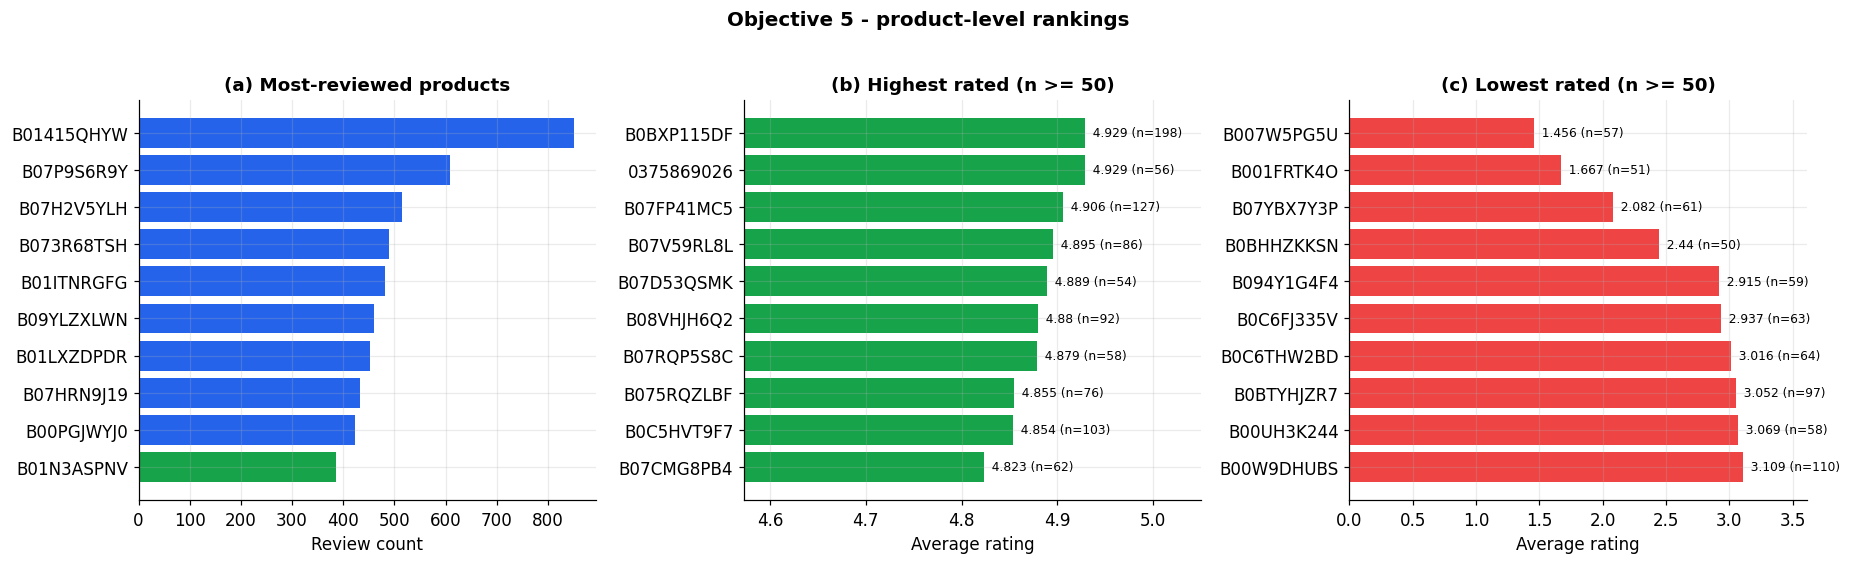

In [25]:
mr = most_reviewed.toPandas()
bp = best_products.toPandas()
wp = worst_products.toPandas()

fig, ax = plt.subplots(1, 3, figsize=(17, 5))

ax[0].barh(mr["parent_asin"][::-1], mr["reviews"][::-1],
           color=[ccol(c) for c in mr["Category"][::-1]])
ax[0].set_title("(a) Most-reviewed products"); ax[0].set_xlabel("Review count")

ax[1].barh(bp["parent_asin"][::-1], bp["avg_rating"][::-1], color="#16a34a")
ax[1].set_title(f"(b) Highest rated (n >= {MIN_REVIEWS})"); ax[1].set_xlabel("Average rating")
ax[1].set_xlim(max(0, bp["avg_rating"].min() - 0.25), 5.05)
for i, (v, n) in enumerate(zip(bp["avg_rating"][::-1], bp["reviews"][::-1])):
    ax[1].text(v, i, f"  {v} (n={n})", va="center", fontsize=8)

ax[2].barh(wp["parent_asin"][::-1], wp["avg_rating"][::-1], color="#ef4444")
ax[2].set_title(f"(c) Lowest rated (n >= {MIN_REVIEWS})"); ax[2].set_xlabel("Average rating")
ax[2].set_xlim(0, max(wp["avg_rating"].max() + 0.5, 1))
for i, (v, n) in enumerate(zip(wp["avg_rating"][::-1], wp["reviews"][::-1])):
    ax[2].text(v, i, f"  {v} (n={n})", va="center", fontsize=8)

plt.suptitle("Objective 5 - product-level rankings", y=1.02, fontsize=13, fontweight="bold")
plt.tight_layout()
savefig(fig, "fig07_product_rankings", "Objective 5 - product rankings with review counts")
plt.show()

## 10. Objective 6 - Customer-Activity Analysis

In [26]:
reviewer = (df.groupBy("user_id")
            .agg(F.count("*").alias("reviews"),
                 F.round(F.avg("rating"), 2).alias("avg_rating"),
                 F.sum("helpful_vote").alias("total_helpful"))).cache()
n_reviewers = reviewer.count()
print(f"Unique reviewers: {n_reviewers:,}")
print(f"Average reviews per reviewer: {n_clean/n_reviewers:.2f}")

top_reviewers = reviewer.orderBy(F.desc("reviews"), F.desc("total_helpful")).limit(10)
print("\nTop 10 most active reviewers")
top_reviewers.show(truncate=False)

activity = (reviewer.withColumn("bucket",
                F.when(F.col("reviews") == 1, "1")
                 .when(F.col("reviews") == 2, "2")
                 .when(F.col("reviews").between(3, 5), "3-5")
                 .when(F.col("reviews").between(6, 10), "6-10")
                 .otherwise("11+"))
            .groupBy("bucket")
            .agg(F.count("*").alias("reviewers"), F.sum("reviews").alias("reviews_contributed")))

act = activity.toPandas()
order = ["1", "2", "3-5", "6-10", "11+"]
act["bucket"] = pd.Categorical(act["bucket"], order, ordered=True)
act = act.sort_values("bucket").reset_index(drop=True)
act["pct_reviewers"] = (100 * act["reviewers"] / n_reviewers).round(2)
act["pct_reviews"] = (100 * act["reviews_contributed"] / n_clean).round(2)
print("Reviewer activity distribution")
print(act.to_string(index=False))

save_table(top_reviewers, "obj6_top_reviewers")
save_table(act, "obj6_activity_distribution");

Unique reviewers: 504,673
Average reviews per reviewer: 1.03

Top 10 most active reviewers
+----------------------------+-------+----------+-------------+
|user_id                     |reviews|avg_rating|total_helpful|
+----------------------------+-------+----------+-------------+
|AG73BVBKUOH22USSFJA5ZWL7AKXA|19     |4.37      |3            |
|AEWLQYBQDYWWUWK6UHHTNWO5AHYA|16     |4.38      |1541         |
|AHJRJCJMK3XVV4BSPBRAHIYEODWA|14     |3.57      |137          |
|AHEDJIDSPVYCB3GPRZKGO7YTK6XQ|12     |4.25      |25           |
|AGUTKSIA7TDKIDLDEGUOY2ZITO6Q|11     |3.45      |1            |
|AGMWACNMAG74AXBF7IJ22IOZSZPA|10     |4.0       |59           |
|AHF2J7WG4CPDF2IOVGZITSHQWFJA|10     |3.9       |6            |
|AENQ4UD7LRPE5DW5BFOTE2UCJRWA|9      |4.67      |35           |
|AGIR72F44THTLBTB46EUF5HCK6IA|8      |3.25      |37           |
|AGFSNYGS5FKRQKPYQOFLZGJFSVAQ|8      |3.63      |14           |
+----------------------------+-------+----------+-------------+

Reviewer act

figure saved -> /kaggle/working/figures/fig08_reviewer_activity.png


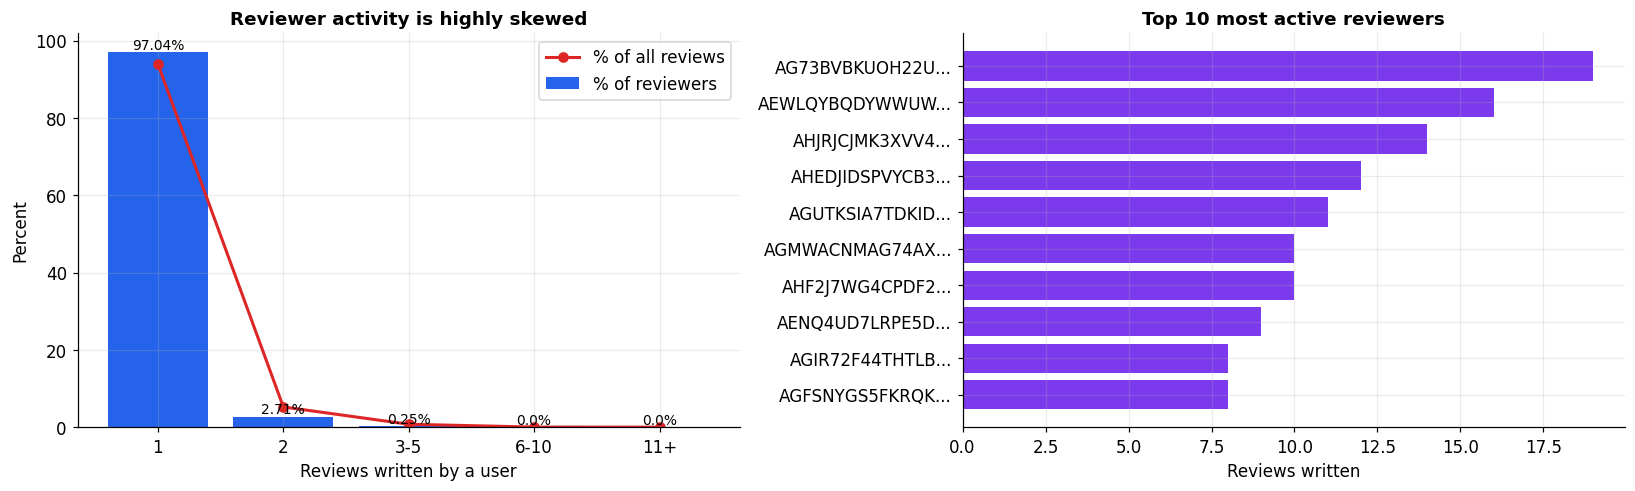

In [27]:
tr = top_reviewers.toPandas()

fig, ax = plt.subplots(1, 2, figsize=(15, 4.6))
x = np.arange(len(act))
ax[0].bar(x, act["pct_reviewers"], color=ACCENT, label="% of reviewers")
ax[0].plot(x, act["pct_reviews"], color="#dc2626", marker="o", lw=2, label="% of all reviews")
ax[0].set_xticks(x); ax[0].set_xticklabels(act["bucket"].astype(str))
ax[0].set_title("Reviewer activity is highly skewed")
ax[0].set_xlabel("Reviews written by a user"); ax[0].set_ylabel("Percent")
ax[0].legend()
for i, v in enumerate(act["pct_reviewers"]):
    ax[0].text(i, v, f"{v}%", ha="center", va="bottom", fontsize=9)

ax[1].barh([u[:14] + "..." for u in tr["user_id"]][::-1], tr["reviews"][::-1], color="#7c3aed")
ax[1].set_title("Top 10 most active reviewers"); ax[1].set_xlabel("Reviews written")

plt.tight_layout()
savefig(fig, "fig08_reviewer_activity", "Objective 6 - reviewer activity distribution")
plt.show()

## 11. Objective 7 - Text Analytics

One clean token stream is built and reused by every text module below. HTML fragments are
stripped first, tokens are restricted to runs of letters, stop-words are removed and tokens of
two characters or fewer are dropped. Without that step the vocabulary fills up with `br`,
punctuation-glued words and empty strings, and the frequency table becomes meaningless.


In [28]:
len_rating = (df.groupBy("rating")
              .agg(F.round(F.avg("review_length")).cast("int").alias("avg_chars"),
                   F.round(F.avg("review_word_count"), 1).alias("avg_words"),
                   F.round(F.expr("percentile_approx(review_length, 0.5)")).cast("int").alias("median_chars"),
                   F.count("*").alias("n"))
              .orderBy("rating"))
print("Review length against star rating")
len_rating.show()
save_table(len_rating, "obj7_length_by_rating");

Review length against star rating


+------+---------+---------+------------+------+
|rating|avg_chars|avg_words|median_chars|     n|
+------+---------+---------+------------+------+
|   1.0|      202|     37.9|         126| 69480|
|   2.0|      275|     51.6|         164| 30760|
|   3.0|      280|     52.7|         158| 38799|
|   4.0|      283|     53.1|         142| 62481|
|   5.0|      164|     30.7|          84|319753|
+------+---------+---------+------------+------+

table saved  -> obj7_length_by_rating  (5 rows)


In [29]:
from pyspark.ml.feature import RegexTokenizer, StopWordsRemover, CountVectorizer, HashingTF, IDF

body = df.select("rating", F.regexp_replace(F.lower("text"), r"<[^>]+>", " ").alias("body"))
tokenizer = RegexTokenizer(inputCol="body", outputCol="tok",
                           pattern=r"[a-z]+", gaps=False, toLowercase=False)
DOMAIN_STOP = StopWordsRemover().getStopWords() + [
    "get", "got", "would", "one", "use", "used", "im", "dont", "br", "also",
    "really", "even", "well", "much", "product", "item"]
remover = StopWordsRemover(inputCol="tok", outputCol="stopped", stopWords=DOMAIN_STOP)

tokenized = (remover.transform(tokenizer.transform(body))
             .withColumn("clean_tokens", F.expr("filter(stopped, x -> length(x) > 2)"))
             .select("rating", "clean_tokens")).cache()
tokenized.count()

top_terms = (tokenized.select(F.explode("clean_tokens").alias("word"))
             .groupBy("word").count().orderBy(F.desc("count")).limit(20))
print("Top 20 corpus terms")
top_terms.show(20, truncate=False)
save_table(top_terms, "obj7_top_terms");

Top 20 corpus terms


+---------+------+
|word     |count |
+---------+------+
|phone    |191435|
|case     |172260|
|great    |122979|
|like     |87684 |
|screen   |87166 |
|good     |83927 |
|love     |67513 |
|game     |60422 |
|easy     |52845 |
|works    |49217 |
|time     |42489 |
|protector|41889 |
|nice     |39173 |
|work     |36992 |
|fit      |35871 |
|quality  |35276 |
|price    |33926 |
|bought   |32439 |
|back     |32042 |
|iphone   |30927 |
+---------+------+



table saved  -> obj7_top_terms  (20 rows)


In [30]:
terms_by_rating = (tokenized.filter(F.col("rating").isin([1.0, 5.0]))
                   .select("rating", F.explode("clean_tokens").alias("word"))
                   .groupBy("rating", "word").count())
w_term = Window.partitionBy("rating").orderBy(F.desc("count"))
top_by_rating = (terms_by_rating.withColumn("rk", F.row_number().over(w_term))
                 .filter(F.col("rk") <= 12).orderBy("rating", "rk"))
print("Most frequent terms in 1-star vs 5-star reviews")
top_by_rating.show(30, truncate=False)
save_table(top_by_rating, "obj7_top_terms_by_rating");

Most frequent terms in 1-star vs 5-star reviews


+------+---------+------+---+
|rating|word     |count |rk |
+------+---------+------+---+
|1.0   |phone    |26799 |1  |
|1.0   |case     |18211 |2  |
|1.0   |screen   |16093 |3  |
|1.0   |work     |9791  |4  |
|1.0   |like     |8421  |5  |
|1.0   |money    |7532  |6  |
|1.0   |protector|7171  |7  |
|1.0   |game     |7029  |8  |
|1.0   |buy      |6792  |9  |
|1.0   |doesn    |6736  |10 |
|1.0   |fit      |6713  |11 |
|1.0   |time     |6678  |12 |
|5.0   |phone    |104644|1  |
|5.0   |great    |94846 |2  |
|5.0   |case     |94021 |3  |
|5.0   |love     |56675 |4  |
|5.0   |good     |49068 |5  |
|5.0   |like     |45911 |6  |
|5.0   |screen   |40668 |7  |
|5.0   |easy     |40257 |8  |
|5.0   |works    |34440 |9  |
|5.0   |game     |29700 |10 |
|5.0   |nice     |24682 |11 |
|5.0   |perfect  |24368 |12 |
+------+---------+------+---+

table saved  -> obj7_top_terms_by_rating  (24 rows)


In [31]:
cv_model = CountVectorizer(inputCol="clean_tokens", outputCol="tf",
                           vocabSize=5000, minDF=5.0).fit(tokenized)
tf_df = cv_model.transform(tokenized)

from pyspark.ml.stat import Summarizer
tf_total = tf_df.select(Summarizer.sum(F.col("tf")).alias("s")).first()["s"].toArray()
vocab = np.array(cv_model.vocabulary)

print(f"CountVectorizer vocabulary (minDF=5): {len(vocab):,} terms")
cv_top = pd.DataFrame({"term": vocab, "corpus_frequency": tf_total.astype("int64")}) \
           .sort_values("corpus_frequency", ascending=False).head(20).reset_index(drop=True)
save_table(cv_top, "obj7_countvectorizer_top_terms")
cv_top

CountVectorizer vocabulary (minDF=5): 5,000 terms
table saved  -> obj7_countvectorizer_top_terms  (20 rows)


,term,corpus_frequency
0,phone,191435
1,case,172260
2,great,122979
3,like,87684
4,screen,87165
5,good,83927
6,love,67513
7,game,60421
8,easy,52845
9,works,49217


In [32]:
hashing_tf = HashingTF(inputCol="clean_tokens", outputCol="raw_features", numFeatures=8192)
featurized = hashing_tf.transform(tokenized)
tfidf = IDF(inputCol="raw_features", outputCol="features").fit(featurized).transform(featurized)

print("TF-IDF vectors built on the same cleaned token stream")
tfidf.select("rating", "features").show(3, truncate=70)

TF-IDF vectors built on the same cleaned token stream
+------+----------------------------------------------------------------------+
|rating|                                                              features|
+------+----------------------------------------------------------------------+
|   5.0|(8192,[633,697,1699,2319,5017,5280,5676,5992,6256,7634,8080],[5.904...|
|   5.0|(8192,[377,697,998,1198,1268,1288,1694,2502,3575,4095,4375,4418,625...|
|   5.0|(8192,[236,697,1712,1857,3051,3918,5039,6324,7913],[5.7285930743861...|
+------+----------------------------------------------------------------------+
only showing top 3 rows


figure saved -> /kaggle/working/figures/fig09_text_analytics.png


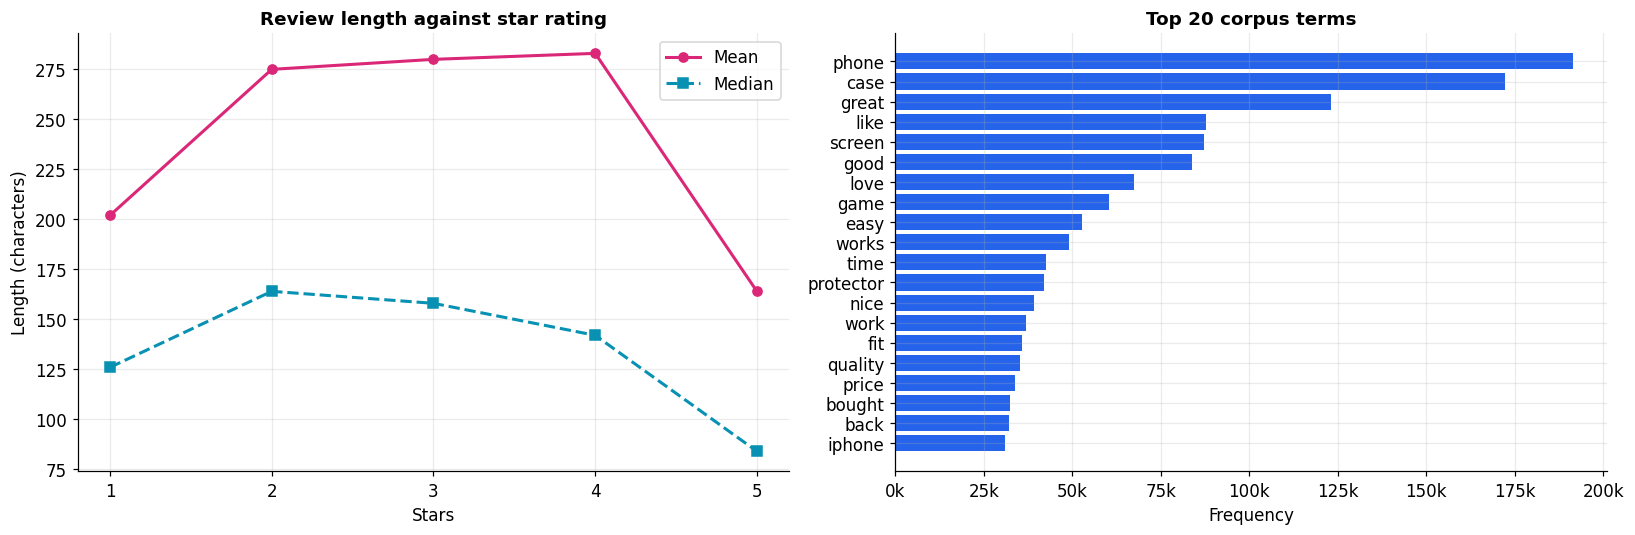

In [33]:
lr = len_rating.toPandas()
tt = top_terms.toPandas()

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].plot(lr["rating"].astype(int), lr["avg_chars"], marker="o", lw=2, color="#db2777", label="Mean")
ax[0].plot(lr["rating"].astype(int), lr["median_chars"], marker="s", lw=2,
           color="#0891b2", ls="--", label="Median")
ax[0].set_title("Review length against star rating")
ax[0].set_xlabel("Stars"); ax[0].set_ylabel("Length (characters)")
ax[0].set_xticks([1, 2, 3, 4, 5]); ax[0].legend()

ax[1].barh(tt["word"][::-1], tt["count"][::-1], color=ACCENT)
ax[1].set_title("Top 20 corpus terms"); ax[1].set_xlabel("Frequency")
ax[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))

plt.tight_layout()
savefig(fig, "fig09_text_analytics", "Objective 7 - length by rating and corpus vocabulary")
plt.show()

### 11.1 Lexicon-based sentiment (optional extension)

The dataset carries no ground-truth sentiment label, so VADER is scored against the star rating
as an informal agreement rate rather than as an accuracy figure. The pass runs on a sample
because a Python UDF cannot be optimised the way a native Spark expression can.


In [34]:
SENTIMENT_SAMPLE_FRAC = 0.04
sentiment_done = False
try:
    try:
        from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
    except ImportError:
        import subprocess, sys
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "vaderSentiment"], check=True)
        from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

    sample = df.select("rating", "text").filter(F.length("text") > 0) \
               .sample(False, SENTIMENT_SAMPLE_FRAC, seed=7).cache()
    n_s = sample.count()

    analyzer = SentimentIntensityAnalyzer()

    def vader_label(t):
        if not t:
            return "neutral"
        c = analyzer.polarity_scores(t)["compound"]
        return "positive" if c >= 0.05 else ("negative" if c <= -0.05 else "neutral")

    vader_udf = F.udf(vader_label, StringType())
    scored = (sample.withColumn("vader", vader_udf(F.col("text")))
                    .withColumn("stars", F.when(F.col("rating") >= 4, "positive")
                                          .when(F.col("rating") <= 2, "negative")
                                          .otherwise("neutral"))).cache()

    agreement = scored.filter(F.col("vader") == F.col("stars")).count() / n_s
    print(f"VADER vs star-rating agreement on {n_s:,} sampled reviews: {agreement:.1%}")

    conf = (scored.groupBy("stars").pivot("vader", ["negative", "neutral", "positive"])
            .count().fillna(0).orderBy("stars"))
    print("Confusion counts (rows = star label, columns = VADER label)")
    conf.show()

    conf_pdf = save_table(conf, "obj7_vader_confusion")
    save_table(pd.DataFrame([{"sampled_reviews": n_s, "agreement_rate": round(agreement, 4)}]),
               "obj7_vader_agreement")
    sentiment_done = True
except Exception as e:
    print("VADER extension skipped:", type(e).__name__, e)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.7 MB/s eta 0:00:00


VADER vs star-rating agreement on 20,723 sampled reviews: 74.8%
Confusion counts (rows = star label, columns = VADER label)
+--------+--------+-------+--------+
|   stars|negative|neutral|positive|
+--------+--------+-------+--------+
|negative|    2066|    700|    1285|
| neutral|     409|    171|     930|
|positive|     649|   1258|   13255|
+--------+--------+-------+--------+

table saved  -> obj7_vader_confusion  (3 rows)
table saved  -> obj7_vader_agreement  (1 rows)


figure saved -> /kaggle/working/figures/fig10_vader_agreement.png


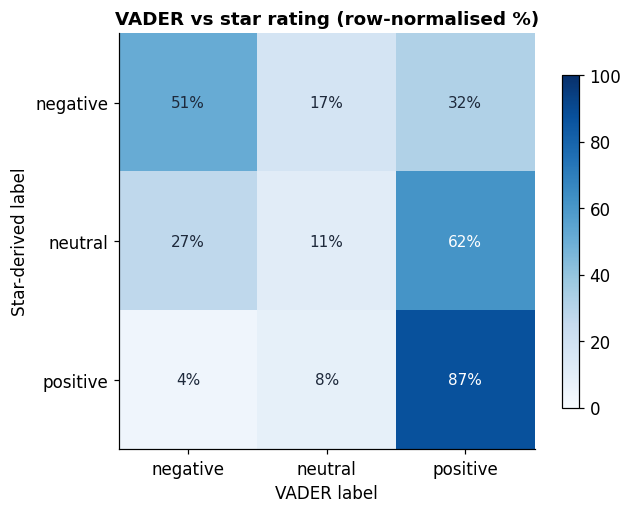

In [35]:
if sentiment_done:
    m = conf_pdf.set_index("stars")[["negative", "neutral", "positive"]].astype(float)
    m = m.reindex([r for r in ["negative", "neutral", "positive"] if r in m.index])
    norm_m = m.div(m.sum(axis=1), axis=0) * 100

    fig, ax = plt.subplots(figsize=(6.2, 4.8))
    im = ax.imshow(norm_m.values, cmap="Blues", vmin=0, vmax=100)
    ax.set_xticks(range(len(norm_m.columns))); ax.set_xticklabels(norm_m.columns)
    ax.set_yticks(range(len(norm_m.index))); ax.set_yticklabels(norm_m.index)
    ax.set_xlabel("VADER label"); ax.set_ylabel("Star-derived label")
    ax.set_title("VADER vs star rating (row-normalised %)")
    ax.grid(False)
    for i in range(norm_m.shape[0]):
        for j in range(norm_m.shape[1]):
            v = norm_m.values[i, j]
            ax.text(j, i, f"{v:.0f}%", ha="center", va="center",
                    color="white" if v > 55 else "#1e293b", fontsize=10)
    fig.colorbar(im, ax=ax, shrink=0.8)
    plt.tight_layout()
    savefig(fig, "fig10_vader_agreement", "Objective 7 - lexicon sentiment against star rating")
    plt.show()
    sample.unpersist(); scored.unpersist()
else:
    print("Sentiment figure skipped because the VADER pass did not run.")

## 12. Objective 8 - Window-Function Based Ranking

Three window patterns are demonstrated: a partitioned ranking, a global ranking, and a rolling
frame. A rolling average of this kind cannot be expressed with `groupBy` at all, because it needs
an ordered frame that moves with each row.


In [36]:
w_cat = Window.partitionBy("Category").orderBy(F.desc("avg_rating"), F.desc("reviews"))
ranked_products = (eligible.withColumn("rank_in_category", F.dense_rank().over(w_cat))
                   .filter(F.col("rank_in_category") <= 3)
                   .orderBy("Category", "rank_in_category"))
print("Top 3 products per category using dense_rank over a category window")
ranked_products.select("Category", "rank_in_category", "parent_asin",
                       "avg_rating", "reviews").show(truncate=False)
save_table(ranked_products, "obj8_top_products_per_category");

Top 3 products per category using dense_rank over a category window
+-----------+----------------+-----------+----------+-------+
|Category   |rank_in_category|parent_asin|avg_rating|reviews|
+-----------+----------------+-----------+----------+-------+
|Beauty     |1               |B085BB7B1M |4.7       |50     |
|Cell Phones|1               |B0BXP115DF |4.929     |198    |
|Cell Phones|2               |B07FP41MC5 |4.906     |127    |
|Cell Phones|3               |B07V59RL8L |4.895     |86     |
|Video Games|1               |0375869026 |4.929     |56     |
|Video Games|2               |B07D53QSMK |4.889     |54     |
|Video Games|3               |B07RQP5S8C |4.879     |58     |
+-----------+----------------+-----------+----------+-------+

table saved  -> obj8_top_products_per_category  (7 rows)


In [37]:
w_rev = Window.orderBy(F.desc("reviews"), F.desc("total_helpful"))
ranked_reviewers = (reviewer.withColumn("activity_rank", F.row_number().over(w_rev))
                    .filter(F.col("activity_rank") <= 10)
                    .select("activity_rank", "user_id", "reviews", "avg_rating", "total_helpful"))
print("Top 10 reviewers using row_number over a global activity window")
ranked_reviewers.show(truncate=False)
save_table(ranked_reviewers, "obj8_ranked_reviewers");

Top 10 reviewers using row_number over a global activity window
+-------------+----------------------------+-------+----------+-------------+
|activity_rank|user_id                     |reviews|avg_rating|total_helpful|
+-------------+----------------------------+-------+----------+-------------+
|1            |AG73BVBKUOH22USSFJA5ZWL7AKXA|19     |4.37      |3            |
|2            |AEWLQYBQDYWWUWK6UHHTNWO5AHYA|16     |4.38      |1541         |
|3            |AHJRJCJMK3XVV4BSPBRAHIYEODWA|14     |3.57      |137          |
|4            |AHEDJIDSPVYCB3GPRZKGO7YTK6XQ|12     |4.25      |25           |
|5            |AGUTKSIA7TDKIDLDEGUOY2ZITO6Q|11     |3.45      |1            |
|6            |AGMWACNMAG74AXBF7IJ22IOZSZPA|10     |4.0       |59           |
|7            |AHF2J7WG4CPDF2IOVGZITSHQWFJA|10     |3.9       |6            |
|8            |AENQ4UD7LRPE5DW5BFOTE2UCJRWA|9      |4.67      |35           |
|9            |AGIR72F44THTLBTB46EUF5HCK6IA|8      |3.25      |37           |


In [38]:
ROLL = 5
w_roll = Window.partitionBy("parent_asin").orderBy("timestamp").rowsBetween(-(ROLL - 1), Window.currentRow)
w_seq = Window.partitionBy("parent_asin").orderBy("timestamp")

rolling = (df.withColumn("rolling_avg_rating", F.round(F.avg("rating").over(w_roll), 3))
             .withColumn("review_seq", F.row_number().over(w_seq)))

busy_product = df.groupBy("parent_asin").count().orderBy(F.desc("count")).first()["parent_asin"]
example = (rolling.filter(F.col("parent_asin") == busy_product)
           .select("review_seq", "event_time", "rating", "rolling_avg_rating")
           .orderBy("review_seq"))
print(f"Trailing-{ROLL} rolling average for the busiest product ({busy_product})")
example.show(10, truncate=False)

ex_pdf = example.toPandas()
save_table(ex_pdf.head(500), "obj8_rolling_average_example");

Trailing-5 rolling average for the busiest product (B01415QHYW)
+----------+-------------------+------+------------------+
|review_seq|event_time         |rating|rolling_avg_rating|
+----------+-------------------+------+------------------+
|1         |2015-09-28 12:38:48|2.0   |2.0               |
|2         |2015-10-03 13:30:47|4.0   |3.0               |
|3         |2015-10-06 23:01:24|4.0   |3.333             |
|4         |2015-10-07 07:09:21|5.0   |3.75              |
|5         |2015-10-08 15:50:21|5.0   |4.0               |
|6         |2015-10-10 08:32:58|5.0   |4.6               |
|7         |2015-10-17 18:27:15|5.0   |4.8               |
|8         |2015-11-11 00:16:54|5.0   |5.0               |
|9         |2015-11-11 21:03:25|5.0   |5.0               |
|10        |2015-11-15 14:01:11|5.0   |5.0               |
+----------+-------------------+------+------------------+
only showing top 10 rows
table saved  -> obj8_rolling_average_example  (500 rows)


figure saved -> /kaggle/working/figures/fig11_rolling_average.png


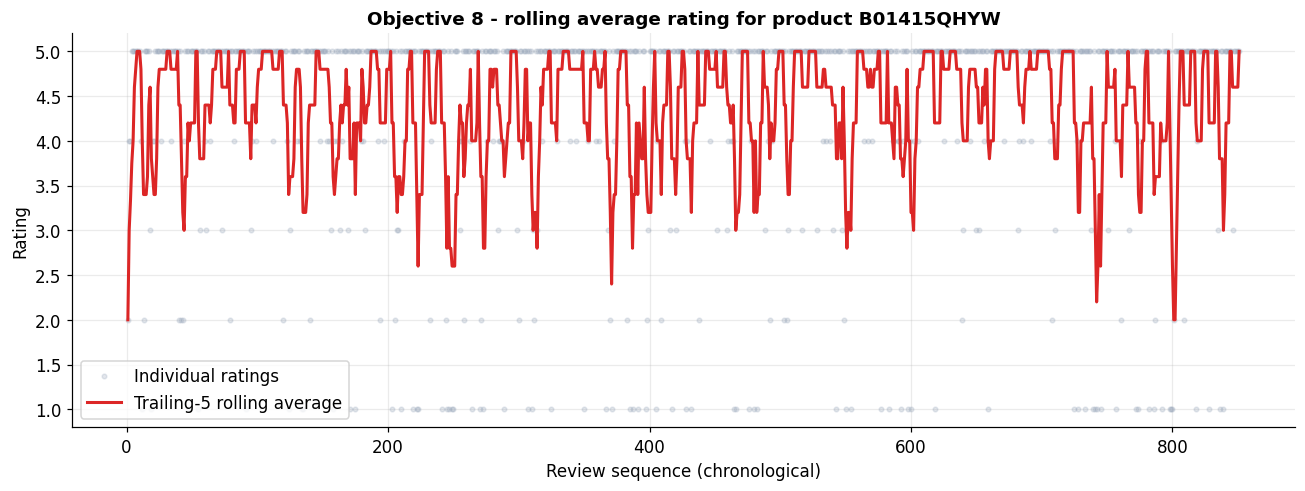

In [39]:
fig, ax = plt.subplots(figsize=(12, 4.6))
ax.plot(ex_pdf["review_seq"], ex_pdf["rating"], alpha=0.25, color="#94a3b8",
        marker=".", linestyle="none", label="Individual ratings")
ax.plot(ex_pdf["review_seq"], ex_pdf["rolling_avg_rating"], color="#dc2626", lw=2,
        label=f"Trailing-{ROLL} rolling average")
ax.set_title(f"Objective 8 - rolling average rating for product {busy_product}")
ax.set_xlabel("Review sequence (chronological)"); ax.set_ylabel("Rating")
ax.set_ylim(0.8, 5.2); ax.legend()
plt.tight_layout()
savefig(fig, "fig11_rolling_average", "Objective 8 - rolling window rating")
plt.show()

## 13. Objective 9 - PySpark versus Pandas Benchmark

Four operations are timed in both engines on identical data at three sizes. Spark is measured
twice: cold, where the DataFrame is uncached and the CSV is read on every run, and warm, where
the data is cached in memory. Each timing is repeated and reported as a mean with its standard
deviation, since a single run on a JVM says very little.


In [40]:
print("Loading the same file into pandas for the head-to-head...")
t0 = time.perf_counter()
pdf_full = pd.read_csv(DATA_PATH)
t_pandas_load = time.perf_counter() - t0
print(f"pandas rows: {len(pdf_full):,}  (read_csv took {t_pandas_load:.2f} s)")
print(f"pandas memory: {pdf_full.memory_usage(deep=True).sum()/1e6:,.0f} MB")

REPEATS_WARM = 5
REPEATS_COLD = 3
FRACTIONS = [0.10, 0.50, 1.00]
OPS = ["groupby_agg", "multi_agg", "filter_count", "sort_take"]

def spark_ops(sdf):
    return {
        "groupby_agg":  lambda: sdf.groupBy("Category").agg(F.avg("rating"), F.count("*")).collect(),
        "multi_agg":    lambda: sdf.groupBy("Category", "rating")
                                   .agg(F.avg("helpful_vote"), F.count("*"), F.max("helpful_vote")).collect(),
        "filter_count": lambda: sdf.filter((F.col("rating") == 5) &
                                           (F.col("verified_purchase") == True)).count(),
        "sort_take":    lambda: sdf.orderBy(F.desc("helpful_vote")).limit(20).collect(),
    }

def pandas_ops(pdf):
    return {
        "groupby_agg":  lambda: pdf.groupby("Category").agg(avg=("rating", "mean"), n=("rating", "size")),
        "multi_agg":    lambda: pdf.groupby(["Category", "rating"]).agg(
                                    a=("helpful_vote", "mean"), n=("helpful_vote", "size"),
                                    m=("helpful_vote", "max")),
        "filter_count": lambda: int(((pdf["rating"] == 5) & (pdf["verified_purchase"] == True)).sum()),
        "sort_take":    lambda: pdf.sort_values("helpful_vote", ascending=False).head(20),
    }

def timed(fn, repeats, warmup=False):
    if warmup:
        fn()
    ts = []
    for _ in range(repeats):
        t = time.perf_counter(); fn(); ts.append(time.perf_counter() - t)
    return float(np.mean(ts)), float(np.std(ts))

print("Benchmark harness ready.")

Loading the same file into pandas for the head-to-head...
pandas rows: 521,607  (read_csv took 3.32 s)
pandas memory: 366 MB
Benchmark harness ready.


In [41]:
rows_out = []

for frac in FRACTIONS:
    cold_src = read_raw(tag=f"cold_{int(frac*100)}")
    warm_src = read_raw(tag=f"warm_{int(frac*100)}")
    if frac < 1.0:
        cold_src = cold_src.sample(False, frac, seed=42)
        warm_src = warm_src.sample(False, frac, seed=42)
    warm_src = warm_src.cache()
    n_rows = warm_src.count()

    pdf_s = pdf_full if frac >= 1.0 else pdf_full.sample(frac=frac, random_state=42)

    s_cold, s_warm, p_ops = spark_ops(cold_src), spark_ops(warm_src), pandas_ops(pdf_s)
    for op in OPS:
        mc, sc = timed(s_cold[op], REPEATS_COLD)
        mw, sw = timed(s_warm[op], REPEATS_WARM, warmup=True)
        mp, sp = timed(p_ops[op], REPEATS_WARM, warmup=True)
        rows_out += [
            (frac, n_rows, op, "PySpark (cold)", mc, sc),
            (frac, n_rows, op, "PySpark (cached)", mw, sw),
            (frac, n_rows, op, "Pandas", mp, sp),
        ]
        print(f"size={frac:>4.0%} ({n_rows:>7,})  {op:<13} "
              f"cold={mc*1000:8.1f} ms   cached={mw*1000:7.1f} ms   pandas={mp*1000:7.1f} ms")

    warm_src.unpersist(); gc.collect()

bench = pd.DataFrame(rows_out, columns=["fraction", "rows", "operation", "engine",
                                        "mean_sec", "std_sec"])
bench["mean_ms"] = (bench["mean_sec"] * 1000).round(2)
bench["std_ms"] = (bench["std_sec"] * 1000).round(2)
bench["reported"] = bench["mean_ms"].map("{:.1f}".format) + " +/- " + bench["std_ms"].map("{:.1f}".format)

print("\nBenchmark summary (mean ms +/- std)")
pivot_bench = bench.pivot_table(index=["operation", "rows"], columns="engine",
                                values="mean_ms", aggfunc="first").round(1)
print(pivot_bench)
save_table(bench, "obj9_benchmark_raw")
save_table(pivot_bench.reset_index(), "obj9_benchmark_summary");

size= 10% ( 52,031)  groupby_agg   cold=   173.5 ms   cached=   93.1 ms   pandas=    9.2 ms
size= 10% ( 52,031)  multi_agg     cold=   278.3 ms   cached=  114.2 ms   pandas=    8.6 ms
size= 10% ( 52,031)  filter_count  cold=    95.5 ms   cached=   64.1 ms   pandas=    0.4 ms
size= 10% ( 52,031)  sort_take     cold=   294.3 ms   cached=   62.2 ms   pandas=   15.2 ms


size= 50% (261,388)  groupby_agg   cold=   163.7 ms   cached=  105.6 ms   pandas=   20.4 ms
size= 50% (261,388)  multi_agg     cold=   199.4 ms   cached=  134.4 ms   pandas=   27.3 ms
size= 50% (261,388)  filter_count  cold=   111.1 ms   cached=   67.0 ms   pandas=    0.8 ms
size= 50% (261,388)  sort_take     cold=   389.0 ms   cached=  164.6 ms   pandas=  106.6 ms


size=100% (521,607)  groupby_agg   cold=   137.5 ms   cached=  131.2 ms   pandas=   34.3 ms
size=100% (521,607)  multi_agg     cold=   173.1 ms   cached=  184.5 ms   pandas=   47.6 ms
size=100% (521,607)  filter_count  cold=    82.1 ms   cached=   75.0 ms   pandas=    1.6 ms
size=100% (521,607)  sort_take     cold=   555.4 ms   cached=  301.6 ms   pandas=  173.8 ms

Benchmark summary (mean ms +/- std)
engine               Pandas  PySpark (cached)  PySpark (cold)
operation    rows                                            
filter_count 52031    0.400            64.100          95.500
             261388   0.800            67.000         111.100
             521607   1.600            75.000          82.100
groupby_agg  52031    9.200            93.100         173.500
             261388  20.400           105.600         163.600
             521607  34.300           131.200         137.500
multi_agg    52031    8.600           114.200         278.300
             261388  27.300          

figure saved -> /kaggle/working/figures/fig12_benchmark_by_operation.png


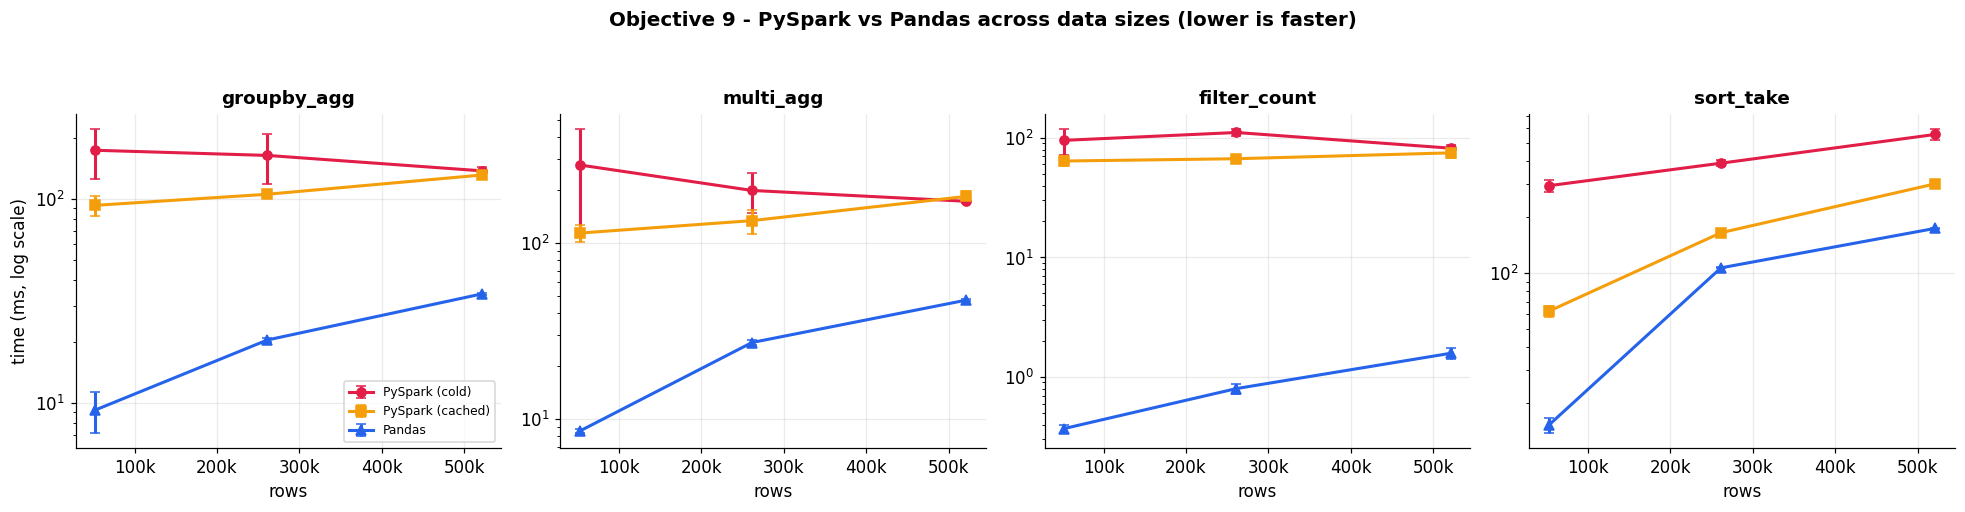

In [42]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.4))
engine_style = {"PySpark (cold)": ("#e11d48", "o"), "PySpark (cached)": ("#f59e0b", "s"),
                "Pandas": ("#2563eb", "^")}
for ax, op in zip(axes, OPS):
    sub = bench[bench["operation"] == op]
    for eng, (color, mk) in engine_style.items():
        s = sub[sub["engine"] == eng].sort_values("rows")
        ax.errorbar(s["rows"], s["mean_ms"], yerr=s["std_ms"], marker=mk, color=color,
                    lw=2, capsize=3, label=eng)
    ax.set_title(op); ax.set_xlabel("rows"); ax.set_yscale("log")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
axes[0].set_ylabel("time (ms, log scale)")
axes[0].legend(fontsize=8)
plt.suptitle("Objective 9 - PySpark vs Pandas across data sizes (lower is faster)",
             y=1.05, fontsize=13, fontweight="bold")
plt.tight_layout()
savefig(fig, "fig12_benchmark_by_operation", "Objective 9 - runtime by operation and size")
plt.show()

figure saved -> /kaggle/working/figures/fig13_benchmark_scaling.png


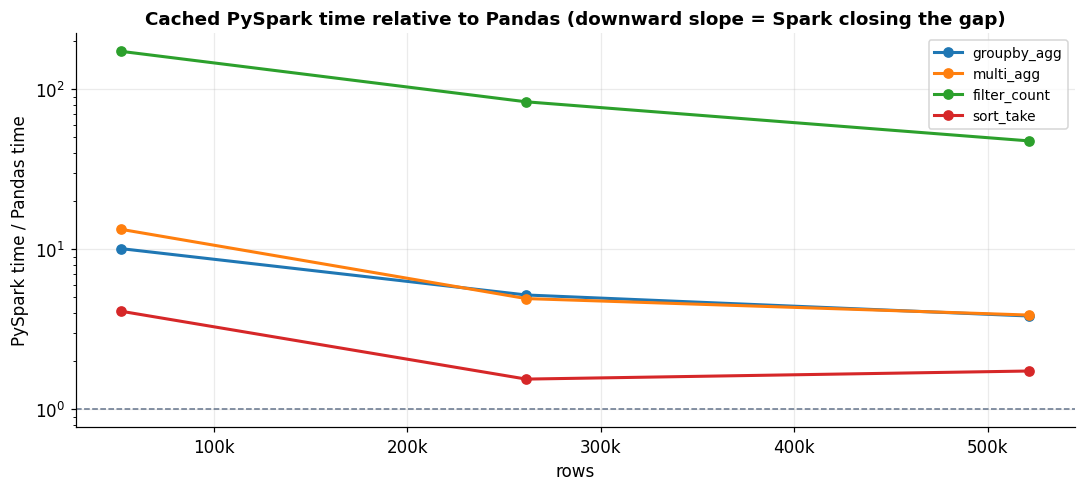

table saved  -> obj9_scaling_ratio  (12 rows)


In [43]:
ratio = (bench[bench["engine"] != "PySpark (cold)"]
         .pivot_table(index=["operation", "rows"], columns="engine", values="mean_sec")
         .assign(ratio=lambda d: d["PySpark (cached)"] / d["Pandas"]).reset_index())

fig, ax = plt.subplots(figsize=(10, 4.6))
for op in OPS:
    s = ratio[ratio["operation"] == op].sort_values("rows")
    ax.plot(s["rows"], s["ratio"], marker="o", lw=2, label=op)
ax.axhline(1.0, color="#64748b", ls="--", lw=1)
ax.set_yscale("log")
ax.set_title("Cached PySpark time relative to Pandas (downward slope = Spark closing the gap)")
ax.set_xlabel("rows"); ax.set_ylabel("PySpark time / Pandas time")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
ax.legend(fontsize=9)
plt.tight_layout()
savefig(fig, "fig13_benchmark_scaling", "Objective 9 - scaling trend of the time ratio")
plt.show()

save_table(ratio, "obj9_scaling_ratio");

## 14. Evaluation Strategy

Most objectives here are descriptive rather than predictive, so evaluation is about correctness
and reproducibility rather than an accuracy score.

### 14.1 Correctness auditing

Every headline aggregate is recomputed in pandas on the same sampled subset and compared against
the Spark result. A mismatch would mean the Spark query is not asking what it appears to ask.


In [44]:
audit_frac = 0.05
audit = df.select("Category", "rating", "verified_purchase", "helpful_vote",
                  "review_length", "user_id", "review_year") \
          .sample(False, audit_frac, seed=11).cache()
a_pdf = audit.toPandas()
print(f"Audit sample: {len(a_pdf):,} rows")

checks = []
def check(name, spark_val, pandas_val, tol=1e-6):
    ok = abs(float(spark_val) - float(pandas_val)) <= tol
    checks.append((name, round(float(spark_val), 6), round(float(pandas_val), 6),
                   "PASS" if ok else "FAIL"))

check("row count", audit.count(), len(a_pdf))
check("mean rating", audit.agg(F.avg("rating")).first()[0], a_pdf["rating"].mean(), 1e-9)
check("verified share", audit.agg(F.avg(F.col("verified_purchase").cast("int"))).first()[0],
      a_pdf["verified_purchase"].mean(), 1e-9)
check("mean helpful votes", audit.agg(F.avg("helpful_vote")).first()[0],
      a_pdf["helpful_vote"].mean(), 1e-9)
check("mean review length", audit.agg(F.avg("review_length")).first()[0],
      a_pdf["review_length"].mean(), 1e-9)
check("count of 5-star", audit.filter(F.col("rating") == 5).count(),
      int((a_pdf["rating"] == 5).sum()))
check("distinct reviewers", audit.select("user_id").distinct().count(),
      a_pdf["user_id"].nunique())
check("max helpful votes", audit.agg(F.max("helpful_vote")).first()[0],
      a_pdf["helpful_vote"].max())

s_cat = (audit.groupBy("Category").agg(F.avg("rating").alias("m"))
         .toPandas().set_index("Category")["m"].sort_index())
p_cat = a_pdf.groupby("Category")["rating"].mean().sort_index()
check("max per-category mean gap", float((s_cat - p_cat).abs().max()), 0.0, 1e-9)

audit_pdf = pd.DataFrame(checks, columns=["check", "spark", "pandas", "result"])
print(audit_pdf.to_string(index=False))
print("\nAll correctness checks passed."
      if (audit_pdf["result"] == "PASS").all() else "\nSome checks FAILED - investigate above.")
save_table(audit_pdf, "eval_correctness_audit")
audit.unpersist();

Audit sample: 26,004 rows
                    check      spark     pandas result
                row count 26,004.000 26,004.000   PASS
              mean rating      4.018      4.018   PASS
           verified share      0.931      0.931   PASS
       mean helpful votes      0.582      0.582   PASS
       mean review length    198.985    198.985   PASS
          count of 5-star 15,902.000 15,902.000   PASS
       distinct reviewers 25,954.000 25,954.000   PASS
        max helpful votes    364.000    364.000   PASS
max per-category mean gap      0.000      0.000   PASS

All correctness checks passed.
table saved  -> eval_correctness_audit  (9 rows)


### 14.2 External consistency

The findings are checked against what the literature reports for review corpora of this kind, so
the numbers are not read in isolation.


In [45]:
five_star_share = float(sat_overall.filter(F.col("rating") == 5).first()["pct"])
verified_share = float(verified_cmp.filter(F.col("verified_purchase") == True).first()["share_pct"])
v_row = verified_cmp.filter(F.col("verified_purchase") == True).first()
nv_row = verified_cmp.filter(F.col("verified_purchase") == False).first()
rating_gap = round(float(v_row["avg_rating"]) - float(nv_row["avg_rating"]), 3)
len_gap = round(float(lr.loc[lr["rating"] == 5, "avg_chars"].iloc[0]) -
                float(lr.loc[lr["rating"] == 1, "avg_chars"].iloc[0]), 1)

consistency = pd.DataFrame([
    ("Positivity skew (Chevalier and Mayzlin, 2006)",
     f"{five_star_share}% of reviews are 5-star",
     "Consistent with the reported positivity bias in online reviews"),
    ("Verified-purchase share",
     f"{verified_share}% verified",
     "High badge coverage, so the badge alone separates very little of the corpus"),
    ("Verified vs non-verified rating gap (He et al., 2022)",
     f"{rating_gap:+} stars",
     "Reported descriptively, not treated as evidence of manipulation"),
    ("Length against rating",
     f"5-star reviews run {len_gap:+.0f} chars vs 1-star",
     "Satisfied customers write less, dissatisfied ones explain at length"),
], columns=["Reference point", "Measured in this pipeline", "Reading"])

save_table(consistency, "eval_external_consistency")
consistency

table saved  -> eval_external_consistency  (4 rows)


,Reference point,Measured in this pipeline,Reading
0,"Positivity skew (Chevalier and Mayzlin, 2006)",61.3% of reviews are 5-star,Consistent with the reported positivity bias i...
1,Verified-purchase share,93.1% verified,"High badge coverage, so the badge alone separa..."
2,Verified vs non-verified rating gap (He et al....,+0.145 stars,"Reported descriptively, not treated as evidenc..."
3,Length against rating,5-star reviews run -38 chars vs 1-star,"Satisfied customers write less, dissatisfied o..."


## 15. Consolidated Findings and Deliverables

In [46]:
best_cat = sat_by_cat.orderBy(F.desc("avg_rating")).first()
worst_cat = sat_by_cat.orderBy(F.asc("avg_rating")).first()
peak_year = yearly.orderBy(F.desc("reviews")).first()
one_review_share = float(act.loc[act["bucket"].astype(str) == "1", "pct_reviewers"].iloc[0]) \
                   if (act["bucket"].astype(str) == "1").any() else float("nan")
speedup = ratio["ratio"].iloc[-1] if len(ratio) else float("nan")

findings = pd.DataFrame([
    ("1. Customer satisfaction",
     f"Average {overall['avg']} stars, {five_star_share}% five-star; "
     f"{best_cat['Category']} highest at {best_cat['avg_rating']}, "
     f"{worst_cat['Category']} lowest at {worst_cat['avg_rating']}"),
    ("2. Verified purchase",
     f"{verified_share}% verified; rating gap {rating_gap:+} stars, "
     f"helpful-vote gap {round(float(v_row['avg_helpful_vote'])-float(nv_row['avg_helpful_vote']),3):+}"),
    ("3. Helpful reviews",
     f"Mean {overall_help['avg']} votes, only {overall_help['pct_any']}% of reviews get any vote"),
    ("4. Temporal trend",
     f"Peak year {peak_year['review_year']} with {peak_year['reviews']:,} reviews; "
     f"2019-2021 was {n_surge/max(n_before,1):.1f}x the 2016-2018 volume"),
    ("5. Product analytics",
     f"{n_eligible:,} of {n_products:,} products clear the {MIN_REVIEWS}-review threshold"),
    ("6. Customer activity",
     f"{n_reviewers:,} reviewers, {one_review_share}% of them wrote exactly one review"),
    ("7. Text analytics",
     f"5-star reviews run {len_gap:+.0f} chars vs 1-star; "
     f"vocabulary of {len(vocab):,} terms at minDF=5"),
    ("8. Window functions",
     f"dense_rank per category, row_number over reviewers, trailing-{ROLL} rolling average"),
    ("9. Benchmark",
     f"Cached PySpark is {speedup:.1f}x Pandas time on the largest sort at full size"),
], columns=["Objective", "Headline result"])

save_table(findings, "final_consolidated_findings")
findings

table saved  -> final_consolidated_findings  (9 rows)


,Objective,Headline result
0,1. Customer satisfaction,"Average 4.021 stars, 61.3% five-star; Video Ga..."
1,2. Verified purchase,"93.1% verified; rating gap +0.145 stars, helpf..."
2,3. Helpful reviews,"Mean 0.704 votes, only 17.1% of reviews get an..."
3,4. Temporal trend,"Peak year 2020 with 70,546 reviews; 2019-2021 ..."
4,5. Product analytics,"712 of 193,772 products clear the 50-review th..."
5,6. Customer activity,"504,673 reviewers, 97.04% of them wrote exactl..."
6,7. Text analytics,5-star reviews run -38 chars vs 1-star; vocabu...
7,8. Window functions,"dense_rank per category, row_number over revie..."
8,9. Benchmark,Cached PySpark is 1.7x Pandas time on the larg...


In [47]:
print(f"Tables written to {TBL_DIR} ({len(RESULTS)} tables, CSV + Parquet)")
for name in sorted(RESULTS):
    print(f"  {name:<38} {len(RESULTS[name]):>6,} rows")

print(f"\nFigures written to {FIG_DIR} ({len(FIGURES)} figures, 300 dpi PNG)")
for name in sorted(FIGURES):
    print(f"  {name}.png")

Tables written to /kaggle/working/results (36 tables, CSV + Parquet)
  eval_correctness_audit                      9 rows
  eval_external_consistency                   4 rows
  final_consolidated_findings                 9 rows
  obj1_rating_distribution                    5 rows
  obj1_rating_mix_by_category                 3 rows
  obj1_satisfaction_by_category               3 rows
  obj2_verified_by_category                   6 rows
  obj2_verified_comparison                    2 rows
  obj3_helpful_by_rating                      5 rows
  obj3_top_helpful_reviews                   10 rows
  obj4_category_yearly                       27 rows
  obj4_yearly_trend                          25 rows
  obj5_best_products                         10 rows
  obj5_most_reviewed_products                10 rows
  obj5_worst_products                        10 rows
  obj6_activity_distribution                  5 rows
  obj6_top_reviewers                         10 rows
  obj7_countvectorizer_top_ter

## 16. Conclusion

The pipeline runs end to end on the full extract: it loads the CSV under a declared schema,
profiles it before cleaning, applies a logged four-step preprocessing pass, derives its features
once into a cached working set, and then answers all nine objectives from that single cached
DataFrame.

Three things are worth carrying into the report. Ratings are J-shaped rather than bell-shaped,
so an average rating on its own hides the shape of the distribution and any product ranking needs
a minimum-review threshold to be meaningful. Helpful votes are concentrated in a small minority
of reviews, so helpfulness is better treated as a rare event than as a continuous score. And the
benchmark shows the shape the Spark literature predicts: Spark carries a fixed scheduling and
JVM overhead that dominates at small sizes, and its relative cost falls as the data grows, which
is the argument for using it here rather than an assumption about it.

Every objective is backed by a saved table and, where it helps, a saved figure, so the report can
be written directly from the contents of the results and figures folders.


In [48]:
for name in ["tokenized", "eligible", "products", "reviewer", "df", "raw"]:
    obj = globals().get(name)
    if obj is not None and hasattr(obj, "unpersist"):
        try:
            obj.unpersist()
        except Exception:
            pass

spark.stop()
print("Spark session stopped. Notebook complete.")

Spark session stopped. Notebook complete.
